# Business Question

A regional airline group operating across Malaysia, Singapore,
Thailand, Indonesia, the Philippines, Vietnam, Australia and Japan wants to
understand what drives ticket pricing and flight delays, to support route pricing
decisions and operational planning.

Targets:
- Regression — Ticket_Price_RM: the fare paid, driven by cabin class, route
distance, airline tier, load factor, event congestion at the destination, and how
last-minute the booking was.
- Classification — Delay_Status: On-Time / Delayed / Cancelled, driven by
destination event congestion, public holidays, weekends, flight duration and
airline tier (class split roughly 51% / 43% / 6%).

Questions:
1. What influences Ticket_Price_RM? (regression)
2. What influences Delay_Status? (classification)

# Dataset Load

In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from kagglehub import KaggleDatasetAdapter

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    train_test_split,
)
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier, XGBRegressor

In [2]:
url = 'https://raw.githubusercontent.com/flydevilz/airline-booking-price/refs/heads/main/Airline_Booking_Wrangling_EDA.csv'
df = pd.read_csv(url)
df.head()

,Booking_ID,Airline_ID,Country,Airline_Tier,Service_Rating,Cabin_Class,Seat_Type,Flight_Duration_Hours,Booking_Channel,Meals_Included,...,Competitor_Avg_Fare_RM,Distance_KM,Review_Score,Promo_Applied,Events_Index_Destination,Ticket_Price_RM,Total_Spend_RM,Extra_Spend_Unscaled,Delay_Status,Satisfaction_Rating
0,102683,AL03,Malaysia,premium,3.0,Economy,Window,3.13,Website,Yes,...,363.74,1106.6,7.71,0,47.7,670.12,762.44,102644,On-Time,2
1,100622,AL02,Malaysia,budget,3.0,Premium Economy,Window,0.75,Walk-in,Yes,...,612.09,1962.9,8.19,1,46.1,935.66,1005.93,67084,On-Time,3
2,103618,AL13,Indonesia,full-service,3.0,Economy,Window,4.00,Mobile App,No,...,971.42,3013.9,6.53,0,47.1,1205.51,1242.60,316269,Delayed,1
3,102688,AL15,thailand,budget,2.0,Economy,Aisle,2.80,mobile app,No,...,439.45,1234.8,5.71,1,66.4,513.22,658.77,53561,On-Time,3
4,101078,AL04,indonesia,full-service,4.0,Economy,Middle,6.99,Walk-in,No,...,721.79,2034.7,10.00,0,73.9,918.65,976.61,230164,Cancelled,5


# Dataset Understanding

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,Booking_ID,Airline_ID,Country,Airline_Tier,Service_Rating,Cabin_Class,Seat_Type,Flight_Duration_Hours,Booking_Channel,Meals_Included,Payment_Type,Passenger_Age,Lead_Time_Days,Departure_Date,Departure_Month,Is_Weekend,Is_Public_Holiday,Load_Factor_Flight,Competitor_Avg_Fare_RM,Distance_KM,Review_Score,Promo_Applied,Events_Index_Destination,Ticket_Price_RM,Total_Spend_RM,Extra_Spend_Unscaled,Delay_Status,Satisfaction_Rating
0,102683,AL03,Malaysia,premium,3.0,Economy,Window,3.13,Website,Yes,Card,51.0,5,2024-10-10,10,0,0,0.836,363.74,1106.6,7.71,0,47.7,670.12,762.44,102644,On-Time,2
1,100622,AL02,Malaysia,budget,3.0,Premium Economy,Window,0.75,Walk-in,Yes,Online,34.0,47,2025-03-15,3,1,0,0.806,612.09,1962.9,8.19,1,46.1,935.66,1005.93,67084,On-Time,3
2,103618,AL13,Indonesia,full-service,3.0,Economy,Window,4.00,Mobile App,No,Online,37.0,87,2025-03-02,3,1,0,0.368,971.42,3013.9,6.53,0,47.1,1205.51,1242.60,316269,Delayed,1
3,102688,AL15,thailand,budget,2.0,Economy,Aisle,2.80,mobile app,No,Cash,28.0,19,2024-10-04,10,0,0,0.920,439.45,1234.8,5.71,1,66.4,513.22,658.77,53561,On-Time,3
4,101078,AL04,indonesia,full-service,4.0,Economy,Middle,6.99,Walk-in,No,Card,45.0,14,2024-10-01,10,0,0,0.648,721.79,2034.7,10.00,0,73.9,918.65,976.61,230164,Cancelled,5


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4326 entries, 0 to 4325
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                4326 non-null   int64  
 1   Airline_ID                4326 non-null   object 
 2   Country                   4326 non-null   object 
 3   Airline_Tier              4326 non-null   object 
 4   Service_Rating            4240 non-null   float64
 5   Cabin_Class               4326 non-null   object 
 6   Seat_Type                 4326 non-null   object 
 7   Flight_Duration_Hours     4326 non-null   float64
 8   Booking_Channel           4326 non-null   object 
 9   Meals_Included            4200 non-null   object 
 10  Payment_Type              4326 non-null   object 
 11  Passenger_Age             4129 non-null   float64
 12  Lead_Time_Days            4326 non-null   int64  
 13  Departure_Date            4326 non-null   object 
 14  Departur

In [6]:
#checking column shape
q = df.shape
print(f"Number of samples: {q[0]}")
print(f"Number of features: {q[1]}")

#duplicate check
w = df.duplicated().sum()
print(f"Duplicated data: {w}")

#checking null
e = df.isnull().sum()
print("Missing value:")
for column, value in e.items():
    print(f"- {column}: {value}")

Number of samples: 4326
Number of features: 28
Duplicated data: 126
Missing value:
- Booking_ID: 0
- Airline_ID: 0
- Country: 0
- Airline_Tier: 0
- Service_Rating: 86
- Cabin_Class: 0
- Seat_Type: 0
- Flight_Duration_Hours: 0
- Booking_Channel: 0
- Meals_Included: 126
- Payment_Type: 0
- Passenger_Age: 197
- Lead_Time_Days: 0
- Departure_Date: 0
- Departure_Month: 0
- Is_Weekend: 0
- Is_Public_Holiday: 0
- Load_Factor_Flight: 65
- Competitor_Avg_Fare_RM: 109
- Distance_KM: 0
- Review_Score: 150
- Promo_Applied: 0
- Events_Index_Destination: 0
- Ticket_Price_RM: 0
- Total_Spend_RM: 0
- Extra_Spend_Unscaled: 0
- Delay_Status: 0
- Satisfaction_Rating: 0


# Data Preprocessing

## Change Data Type

In [7]:
#change datatype
df["Booking_ID"] = df["Booking_ID"].astype(str)
df["Departure_Date"] = pd.to_datetime(df["Departure_Date"])

In [8]:
#convert to boolean
df["Is_Weekend"] = df["Is_Weekend"].astype(bool)
df["Is_Public_Holiday"] = df["Is_Public_Holiday"].astype(bool)
df["Promo_Applied"] = df["Promo_Applied"].astype(bool)



Several variables were converted to more appropriate data types to improve data consistency and support further analysis.

- `Booking_ID` was converted from integer to string because it serves as a unique identifier rather than a numerical feature.
- `Departure_Date` was converted to the `datetime` format to enable date-related analysis and feature engineering.
- `Is_Weekend`, `Is_Public_Holiday`, and `Promo_Applied` were converted to Boolean (`True`/`False`) as they represent binary variables, improving readability and ensuring correct interpretation during analysis.

## Duplicate Handling

In [9]:
df['Booking_ID'].duplicated().sum()

np.int64(126)

In [10]:
#remove the duplicated booking ID
df.drop_duplicates(subset=['Booking_ID'], inplace=True)

126 duplicate records were identified and removed because duplicate observations may bias statistical analysis and machine learning model performance.

## Text Standarization

In [11]:
# Remove whitespace from all object columns
object_cols = df.select_dtypes(include="object").columns

for col in object_cols:
    df[col] = df[col].str.strip()

# Standardize capitalization only for selected categorical columns
text_cols = [
    "Country",
    "Cabin_Class",
    "Booking_Channel",
    "Seat_Type",
    "Payment_Type",
    "Airline_Tier",
    "Delay_Status"
]

for col in text_cols:
    df[col] = df[col].str.title()

Before encoding, all categorical variables were cleaned by removing leading/trailing whitespace and standardizing capitalization (e.g., "Malaysia", "malaysia", and "MALAYSIA" were unified into "Malaysia"). This prevented duplicate categories that could negatively affect exploratory analysis and machine learning model performance.

## Handling Missing Value

### Numerical Column Impute

In [12]:
#skewness check
num_cols = [
    "Passenger_Age",
    "Review_Score",
    "Competitor_Avg_Fare_RM",
    "Service_Rating",
    "Load_Factor_Flight"
]

df[num_cols].skew()

,0
Passenger_Age,1.139862
Review_Score,-0.120045
Competitor_Avg_Fare_RM,0.980470
Service_Rating,-0.069113
Load_Factor_Flight,-0.179979


In [13]:
#numerical columns with median


for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_852/1085950225.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Before selecting the imputation method, the skewness of the numerical variables was examined. The results showed that Passenger_Age (skewness = 1.167) and Competitor_Avg_Fare_RM (skewness = 1.004) were positively skewed, while the remaining variables exhibited approximately symmetric distributions. Because the median is more robust to skewed distributions and less influenced by extreme values than the mean, median imputation was selected for all numerical variables. This approach preserves the central tendency of the data while minimizing the impact of potential outliers and ensuring a complete dataset for subsequent machine learning analysis.

### Meals_Included Impute

In [14]:
#inspect dataset by Airline_ID with missing value
(
    df.groupby("Airline_ID")["Meals_Included"]
      .value_counts(dropna=False)
      .unstack(fill_value=0)
)

Meals_Included,No,Yes,NaN
Airline_ID,,,
AL01,131,80,8
AL02,138,84,6
AL03,148,108,8
AL04,134,90,7
AL05,125,92,10
AL06,155,89,1
AL07,134,76,3
AL08,145,93,7
AL09,133,109,9


In [15]:
(
    df.groupby("Cabin_Class")["Meals_Included"]
      .value_counts(dropna=False)
      .unstack(fill_value=0)
)

Meals_Included,No,Yes,NaN
Cabin_Class,,,
Business,339,210,10
Economy,1503,1002,80
First,104,73,5
Premium Economy,484,359,31


In [16]:
# Impute missing values using the mode
df["Meals_Included"] = df["Meals_Included"].fillna(
    df["Meals_Included"].mode()[0]
)

# Encode binary categorical variable
df["Meals_Included"] = df["Meals_Included"].map({
    "Yes": 1,
    "No": 0
})

# Convert to boolean data type
df["Meals_Included"] = df["Meals_Included"].astype(bool)


Before imputation, the missing values in `Meals_Included` were examined across `Airline_ID` and `Cabin_Class`. The analysis showed that the missing values were distributed across different groups without any clear systematic pattern. Since only **126 observations (2.91%)** were missing, the missing values were imputed using the mode ("No"), which preserves the overall category distribution while minimizing data loss.

After imputation, the variable was encoded into a binary numerical format (`Yes` = 1, `No` = 0) to make it suitable for machine learning algorithms.

## Outlier Check and Handling

In [17]:
#statistics
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

print("List of numerical columns:")
print(numerical_columns)
print("\n")

for col in numerical_columns:
    print(f"--- Describing column: {col} ---")
    print(df[col].describe())
    print("\n")

List of numerical columns:
['Service_Rating', 'Flight_Duration_Hours', 'Passenger_Age', 'Lead_Time_Days', 'Departure_Month', 'Load_Factor_Flight', 'Competitor_Avg_Fare_RM', 'Distance_KM', 'Review_Score', 'Events_Index_Destination', 'Ticket_Price_RM', 'Total_Spend_RM', 'Extra_Spend_Unscaled', 'Satisfaction_Rating']


--- Describing column: Service_Rating ---
count    4200.000000
mean        3.374286
std         0.909009
min         1.000000
25%         3.000000
50%         3.000000
75%         4.000000
max         5.000000
Name: Service_Rating, dtype: float64


--- Describing column: Flight_Duration_Hours ---
count    4200.000000
mean        3.979055
std         2.274313
min         0.750000
25%         2.280000
50%         3.580000
75%         5.200000
max        16.000000
Name: Flight_Duration_Hours, dtype: float64


--- Describing column: Passenger_Age ---
count    4200.000000
mean       36.078095
std        11.946220
min        -5.000000
25%        28.000000
50%        36.000000
75%

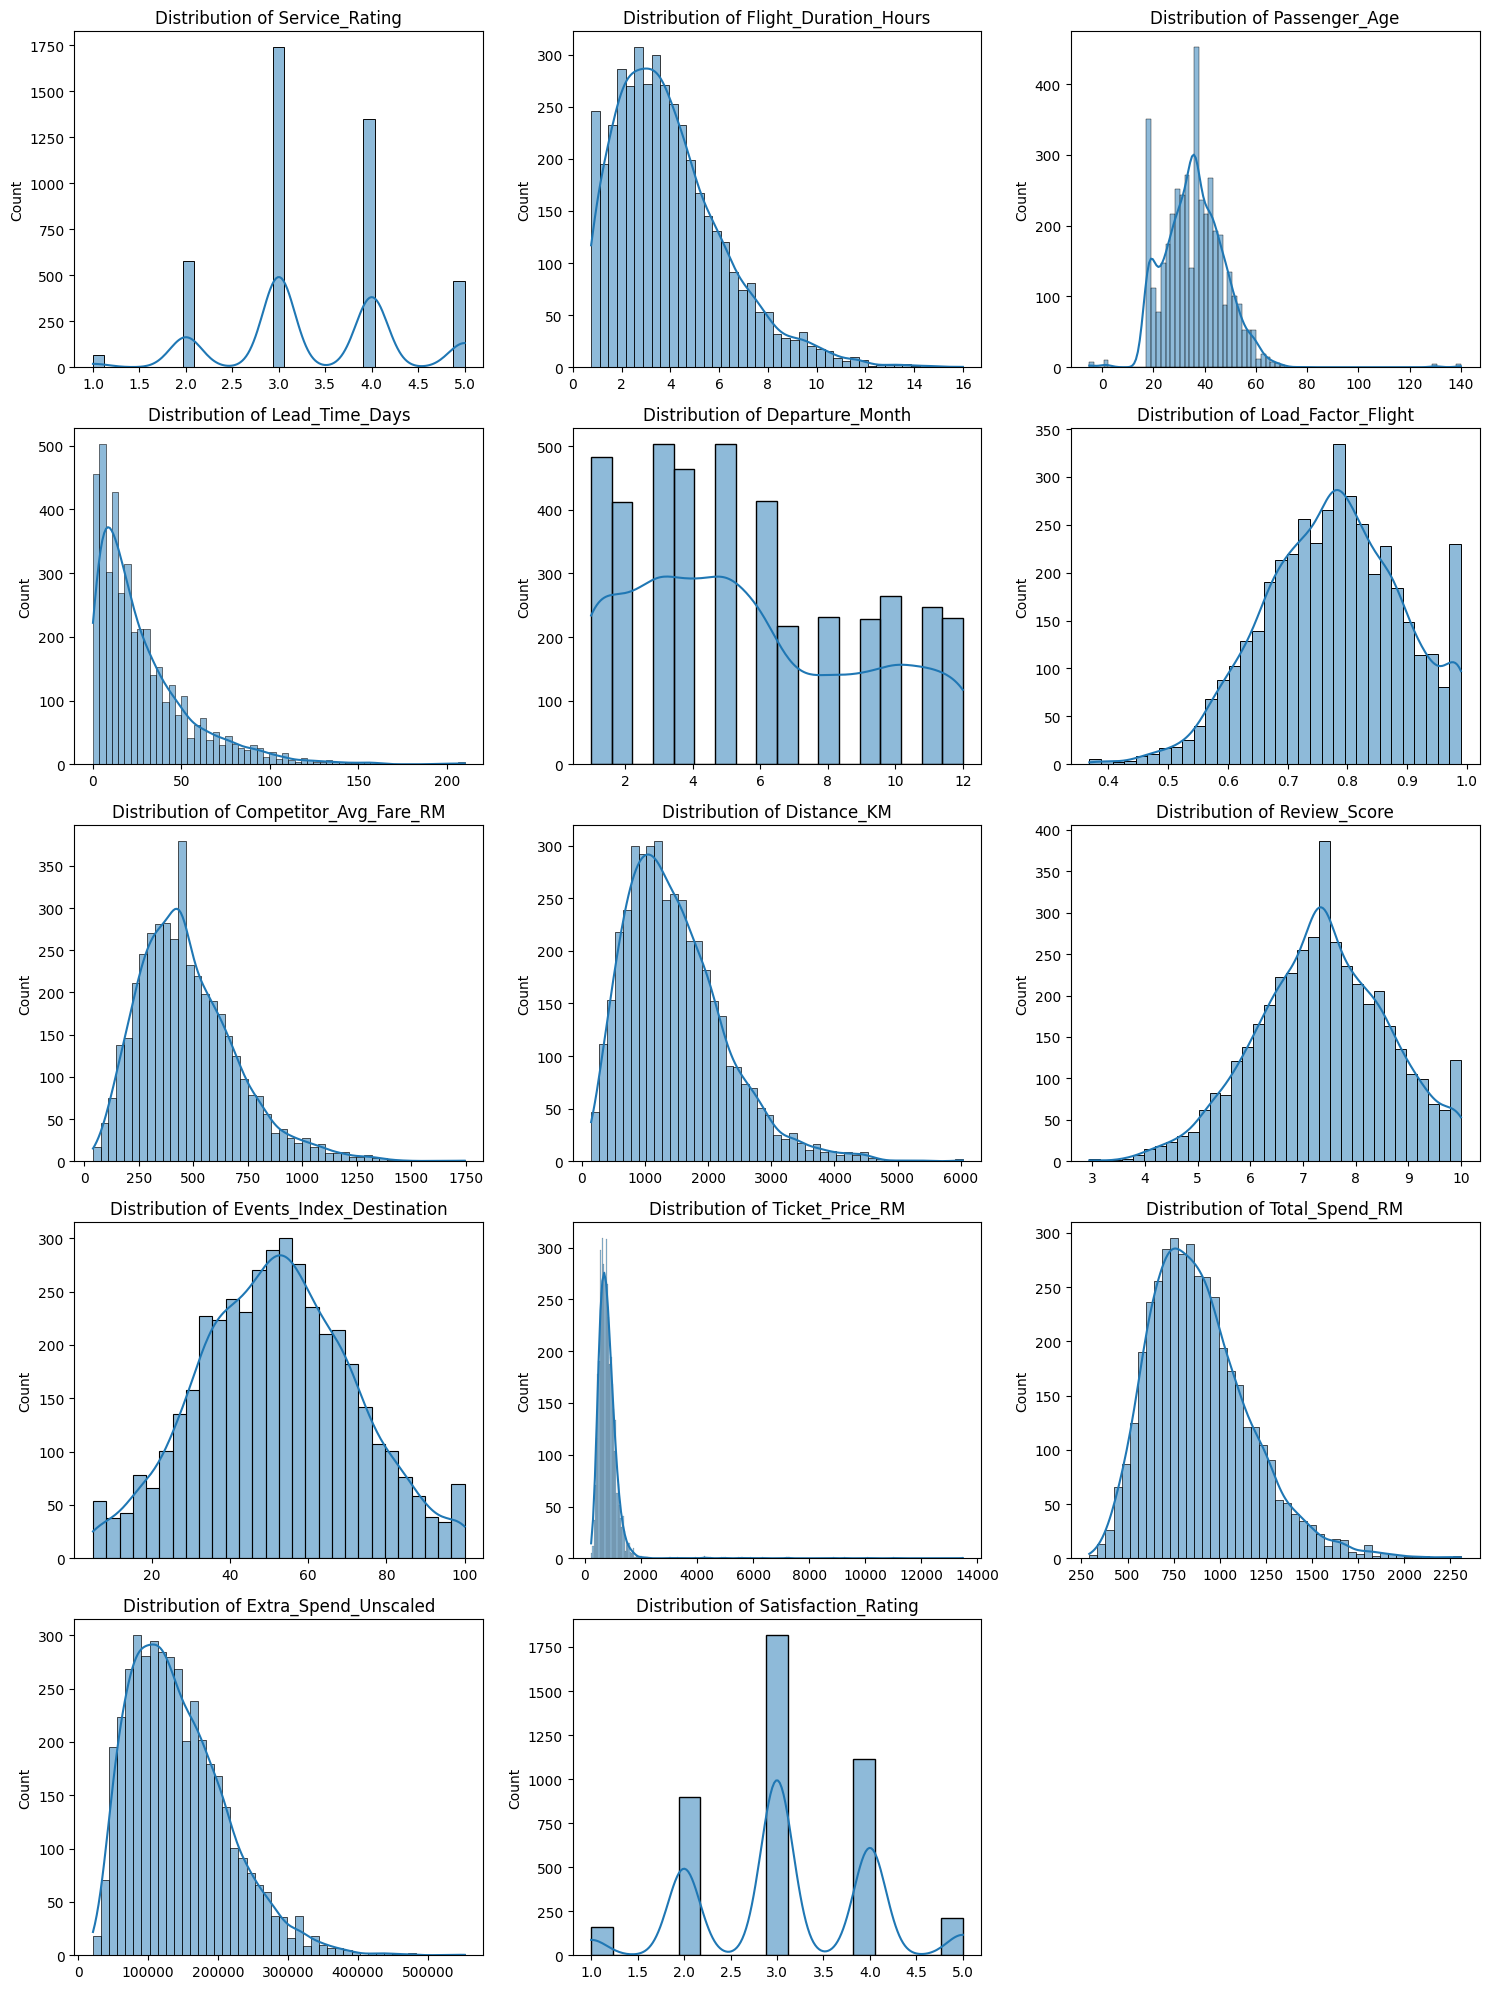

In [18]:
plt.figure(figsize=(15, 20))
for i, col in enumerate(numerical_columns):
    plt.subplot(5, 3, i + 1) # Adjust grid size as needed
    sns.histplot(df[col], kde=True) # kde=True adds a kernel density estimate
    plt.title(f'Distribution of {col}')
    plt.xlabel('') # Remove x-label to avoid clutter
plt.tight_layout()
plt.show()

### Handling Impossible Number

In [19]:
#checking impossible number
a = df[(df["Passenger_Age"] < 0) | (df["Passenger_Age"] > 100)]
display(a)

,Booking_ID,Airline_ID,Country,Airline_Tier,Service_Rating,Cabin_Class,Seat_Type,Flight_Duration_Hours,Booking_Channel,Meals_Included,Payment_Type,Passenger_Age,Lead_Time_Days,Departure_Date,Departure_Month,Is_Weekend,Is_Public_Holiday,Load_Factor_Flight,Competitor_Avg_Fare_RM,Distance_KM,Review_Score,Promo_Applied,Events_Index_Destination,Ticket_Price_RM,Total_Spend_RM,Extra_Spend_Unscaled,Delay_Status,Satisfaction_Rating
1036,102325,AL14,Australia,Full-Service,5.0,Economy,Middle,2.48,Website,True,Card,-5.0,39,2024-06-29,6,True,True,0.977,439.63,209.2,6.14,True,61.3,333.45,447.87,93058,Delayed,2
1058,100227,AL17,Malaysia,Full-Service,3.0,Business,Window,1.96,Walk-In,False,Online,130.0,27,2024-06-07,6,False,False,0.661,295.09,475.0,7.15,False,66.9,616.72,691.52,162550,On-Time,4
2017,100046,AL03,Australia,Premium,3.0,Business,Window,3.02,Walk-In,True,Cash,140.0,14,2024-02-29,2,False,False,0.718,662.02,2310.6,5.86,False,54.7,1273.27,1343.29,211021,On-Time,2
2480,101322,AL02,Singapore,Budget,2.0,Economy,Aisle,1.87,Website,False,Online,-5.0,29,2025-02-25,2,False,False,0.884,300.31,1045.3,7.31,False,40.6,652.59,740.53,184572,Delayed,1
2729,102237,AL09,Philippines,Budget,3.0,Economy,Window,2.16,Airport Counter,False,Card,-5.0,11,2025-06-25,6,False,False,0.744,457.83,1548.0,6.33,True,67.7,778.99,863.89,64083,Delayed,2
2921,100334,AL07,Philippines,Full-Service,3.0,Premium Economy,Window,1.15,Mobile App,False,Online,-5.0,16,2025-01-19,1,True,False,0.774,434.06,1416.5,9.53,False,91.6,871.21,1013.85,93786,On-Time,4
2964,100817,AL05,Thailand,Budget,3.0,Premium Economy,Window,1.73,Walk-In,False,Card,130.0,100,2025-06-12,6,False,False,0.663,423.71,1272.8,8.10,True,73.4,688.18,815.84,105742,On-Time,4
3260,102122,AL15,Vietnam,Budget,3.0,Premium Economy,Aisle,2.37,Mobile App,False,Card,-5.0,10,2024-09-10,9,False,False,0.778,529.91,1341.6,8.37,False,43.8,773.71,827.74,61931,On-Time,4
3282,100866,AL04,Malaysia,Full-Service,3.0,Economy,Aisle,5.89,Mobile App,True,Card,-5.0,116,2024-10-02,10,False,False,0.700,432.37,1269.9,6.86,False,90.1,735.18,958.57,186109,On-Time,3
3554,101399,AL02,Malaysia,Budget,3.0,Business,Middle,2.70,Mobile App,False,Online,130.0,81,2024-08-07,8,False,False,0.731,927.76,2757.9,9.38,False,53.3,1355.92,1462.38,342575,Delayed,5


In [20]:
df.loc[
    (df["Passenger_Age"] < 0) |
    (df["Passenger_Age"] > 100),
    "Passenger_Age"
] = np.nan

df["Passenger_Age"] = df["Passenger_Age"].fillna(
    df["Passenger_Age"].median()
)

The `Passenger_Age` variable contained unrealistic values (`-5`, `130`, and `140` years), which were identified as data entry errors rather than genuine observations. These invalid values were replaced with missing values (`NaN`) and subsequently imputed using the median age to preserve the dataset while minimizing the impact of extreme values.

### Outlier Analysis

In [21]:
outlier_cols = [
    "Passenger_Age",
    "Flight_Duration_Hours",
    "Lead_Time_Days",
    "Load_Factor_Flight",
    "Competitor_Avg_Fare_RM",
    "Distance_KM",
    "Ticket_Price_RM",
    "Total_Spend_RM",
    "Extra_Spend_Unscaled"
]

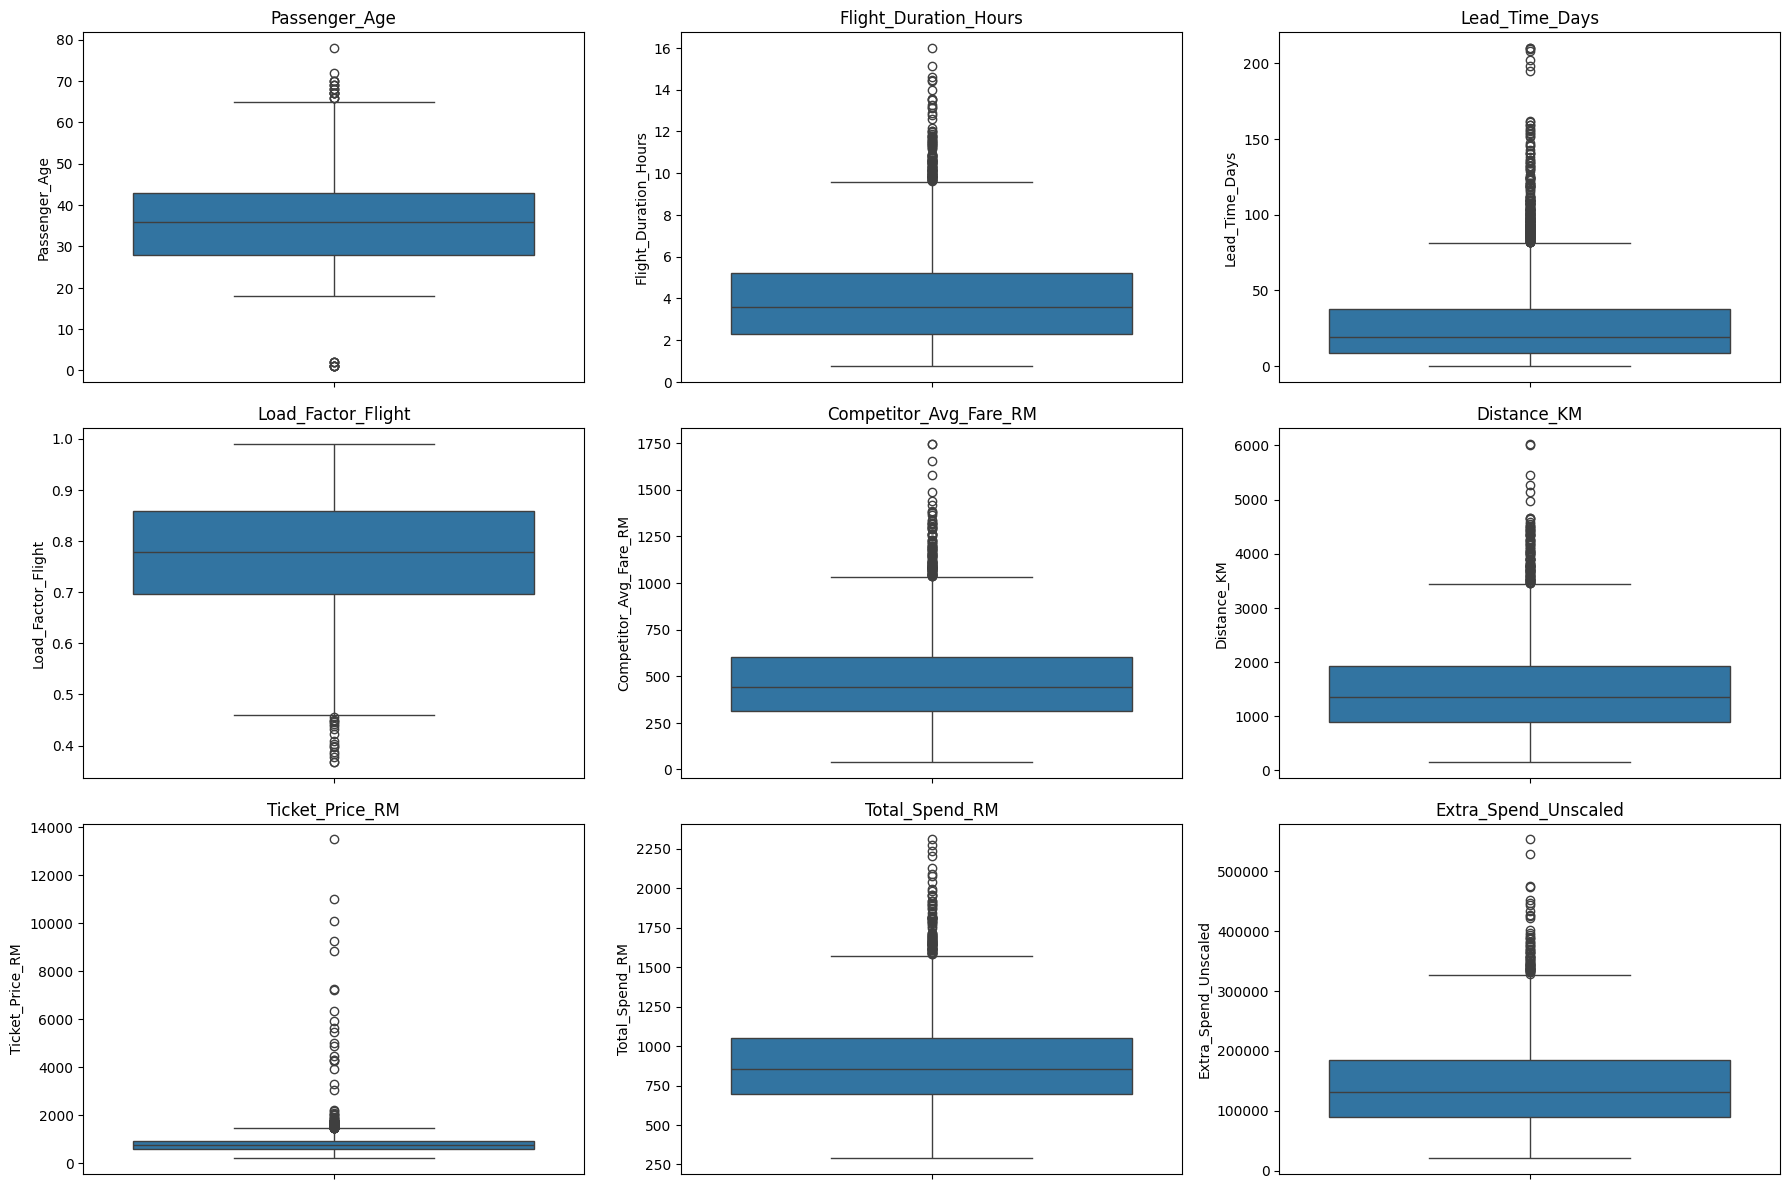

In [22]:
plt.figure(figsize=(18, 12))

for i, col in enumerate(outlier_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

Boxplots were used to visually identify potential outliers in continuous numerical variables. Variables with naturally bounded ranges (e.g., ratings and binary variables) were excluded, as extreme values in these variables are constrained by design and are not considered meaningful outliers.

In [23]:
outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    outlier_summary.append({
        "Variable": col,
        "Outliers": len(outliers),
        "Percentage (%)": round(len(outliers) / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Variable,Outliers,Percentage (%)
0,Passenger_Age,29,0.69
1,Flight_Duration_Hours,103,2.45
2,Lead_Time_Days,225,5.36
3,Load_Factor_Flight,17,0.40
4,Competitor_Avg_Fare_RM,102,2.43
5,Distance_KM,98,2.33
6,Ticket_Price_RM,105,2.50
7,Total_Spend_RM,88,2.10
8,Extra_Spend_Unscaled,64,1.52


Potential outliers were identified using the IQR method and visualized with boxplots. Several variables, including `Ticket_Price_RM`, `Distance_KM`, `Lead_Time_Days`, and `Competitor_Avg_Fare_RM`, contained observations outside the IQR thresholds.

However, these values were retained because they represent plausible business scenarios, such as premium ticket purchases, long-haul flights, advance bookings, and high-spending customers, rather than data entry errors. Retaining these observations preserves valuable information for machine learning models and better reflects real-world airline booking behavior.

The only exceptions were the invalid values identified in `Passenger_Age` (e.g., `-5`, `130`, and `140` years), which were treated as data quality issues rather than genuine outliers and were handled during the data cleaning stage.

### Price Outlier Analysis

In [24]:
df_high_price = df[df['Ticket_Price_RM'] > 4000]

# Display essential variables for high-priced tickets
print("Flights with Ticket Price > 4000 RM:")
df_high_price[[
    "Ticket_Price_RM",
    "Airline_Tier",
    "Cabin_Class",
    "Distance_KM",
    "Flight_Duration_Hours",
    "Promo_Applied",
    "Lead_Time_Days"
]].sort_values(by="Ticket_Price_RM", ascending=False)

Flights with Ticket Price > 4000 RM:


,Ticket_Price_RM,Airline_Tier,Cabin_Class,Distance_KM,Flight_Duration_Hours,Promo_Applied,Lead_Time_Days
1898,13477.784407,Budget,Premium Economy,2675.0,5.77,False,8
1512,11017.561543,Budget,Economy,2391.0,2.59,False,36
1984,10084.548768,Budget,Premium Economy,1437.0,1.37,False,22
3411,9243.049324,Full-Service,Economy,1963.4,0.82,False,69
2987,8852.205025,Premium,Premium Economy,2898.6,2.99,False,0
3863,7261.257141,Budget,Economy,1683.6,10.33,False,14
2711,7212.769073,Premium,Business,892.0,5.00,False,6
2384,6341.193532,Full-Service,First,875.5,5.50,False,47
860,5904.674891,Budget,Economy,1665.8,0.82,False,0
3396,5626.413456,Premium,Economy,653.8,1.71,False,1


In [25]:
d = df.copy()

d["Average_Speed"] = (
    d["Distance_KM"] /
    d["Flight_Duration_Hours"]
)

d.nlargest(20, "Average_Speed")[
    [
        "Ticket_Price_RM",
        "Distance_KM",
        "Flight_Duration_Hours",
        "Average_Speed"
    ]
]

,Ticket_Price_RM,Distance_KM,Flight_Duration_Hours,Average_Speed
2701,1847.14,4556.0,0.89,5119.101124
3128,1561.87,3801.2,0.75,5068.266667
1429,1908.86,4663.6,0.97,4807.835052
1538,1393.53,3459.5,0.75,4612.666667
141,1095.55,3299.0,0.75,4398.666667
1867,1205.79,3017.5,0.75,4023.333333
3875,1166.85,2912.3,0.75,3883.066667
3559,1168.57,3056.2,0.79,3868.607595
429,1301.85,2867.9,0.76,3773.552632
2879,1206.63,2734.0,0.75,3645.333333


In [26]:
d["Average_Speed"].describe()

,Average_Speed
count,4200.000000
mean,536.299037
std,523.097881
min,17.543860
25%,218.313525
50%,377.026373
75%,666.730927
max,5119.101124


An additional validation was performed by calculating the implied average flight speed (Distance_KM / Flight_Duration_Hours). Several observations exhibited unrealistic speeds, indicating that the synthetic dataset does not fully preserve the physical relationship between flight distance and duration. As both original variables remained within individually plausible ranges, they were retained for analysis, while the derived average speed was not used as a modelling feature.

## Check Data Leakage

In [27]:
leakage_cols = [
    "Ticket_Price_RM",
    "Total_Spend_RM",
    "Extra_Spend_Unscaled"
]

df[leakage_cols].corr()

,Ticket_Price_RM,Total_Spend_RM,Extra_Spend_Unscaled
Ticket_Price_RM,1.000000,0.525272,0.339797
Total_Spend_RM,0.525272,1.000000,0.634955
Extra_Spend_Unscaled,0.339797,0.634955,1.000000


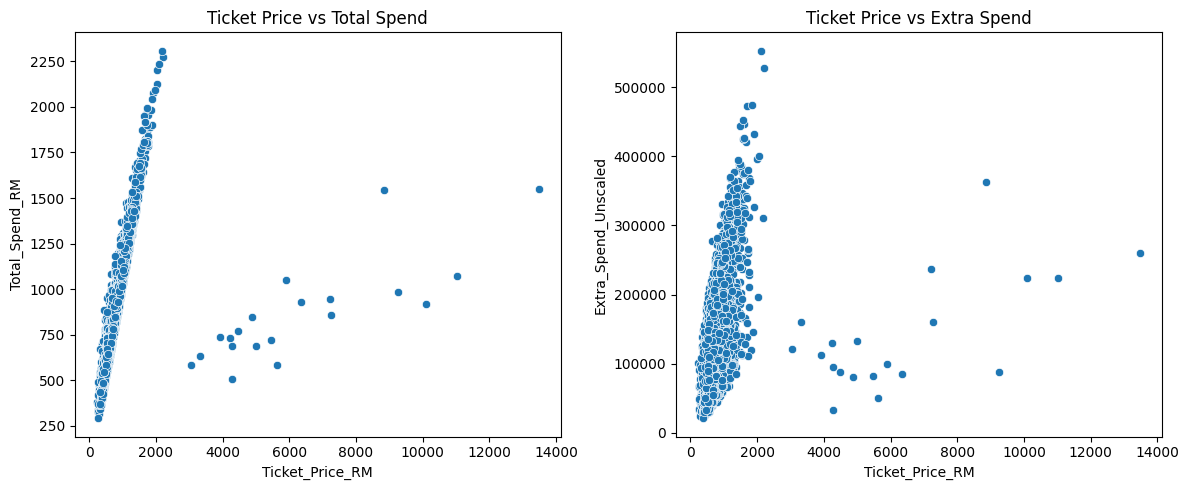

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.scatterplot(
    data=df,
    x="Ticket_Price_RM",
    y="Total_Spend_RM",
    ax=axes[0]
)
axes[0].set_title("Ticket Price vs Total Spend")

sns.scatterplot(
    data=df,
    x="Ticket_Price_RM",
    y="Extra_Spend_Unscaled",
    ax=axes[1]
)
axes[1].set_title("Ticket Price vs Extra Spend")

plt.tight_layout()
plt.show()

In [29]:
df1 = df.copy()
df1["Spend_Difference"] = (
    df1["Total_Spend_RM"] -
    df1["Ticket_Price_RM"]
)

df1["Spend_Difference"].describe()

,Spend_Difference
count,4200.000000
mean,83.421871
std,429.810622
min,-11927.254407
25%,65.875000
50%,97.870000
75%,142.140000
max,431.880000


In [30]:
df1[df1["Spend_Difference"] < 0][[
    "Ticket_Price_RM",
    "Total_Spend_RM",
    "Extra_Spend_Unscaled",
    "Spend_Difference"
]].sort_values("Spend_Difference")

,Ticket_Price_RM,Total_Spend_RM,Extra_Spend_Unscaled,Spend_Difference
1898,13477.784407,1550.53,259927,-11927.254407
1512,11017.561543,1070.31,223490,-9947.251543
1984,10084.548768,918.37,223856,-9166.178768
3411,9243.049324,982.51,88293,-8260.539324
2987,8852.205025,1544.45,363049,-7307.755025
3863,7261.257141,857.44,159737,-6403.817141
2711,7212.769073,947.13,236545,-6265.639073
2384,6341.193532,930.26,85243,-5410.933532
3396,5626.413456,581.98,49779,-5044.433456
860,5904.674891,1050.50,99863,-4854.174891


Potential data leakage was assessed by examining the relationships between `Ticket_Price_RM`, `Total_Spend_RM`, and `Extra_Spend_Unscaled` using correlation analysis and scatter plots.

The correlation analysis showed moderate relationships (`r = 0.53` between `Ticket_Price_RM` and `Total_Spend_RM`), indicating that the variables are related but not highly correlated. Scatter plots also showed considerable variation rather than a deterministic linear relationship.

A small number of observations were identified where `Total_Spend_RM` was lower than `Ticket_Price_RM`, suggesting minor inconsistencies in the synthetic dataset rather than evidence of data leakage. Since these cases represent only a small proportion of the data and there is no indication that the predictor variables directly encode the target variable, all features were retained for subsequent modelling.

In [31]:
df1[df1["Spend_Difference"] < 0][[
    "Ticket_Price_RM",
    "Total_Spend_RM",
    "Promo_Applied",
    "Cabin_Class",
    "Payment_Type",
    "Booking_Channel",
    "Airline_Tier",
    "Distance_KM",
    "Lead_Time_Days",
    "Passenger_Age"
]]

,Ticket_Price_RM,Total_Spend_RM,Promo_Applied,Cabin_Class,Payment_Type,Booking_Channel,Airline_Tier,Distance_KM,Lead_Time_Days,Passenger_Age
454,4235.711550,733.94,True,Premium Economy,Online,Mobile App,Premium,543.1,11,38.0
860,5904.674891,1050.50,False,Economy,Card,Mobile App,Budget,1665.8,0,18.0
1145,4871.742410,849.38,False,Economy,Card,Website,Budget,1319.5,22,25.0
1305,3307.254461,633.04,False,Economy,Card,Website,Full-Service,690.5,21,29.0
1512,11017.561543,1070.31,False,Economy,Card,Website,Budget,2391.0,36,47.0
1774,4287.987911,691.21,True,Economy,Card,Travel Agent,Full-Service,1001.5,4,35.0
1898,13477.784407,1550.53,False,Premium Economy,Online,Mobile App,Budget,2675.0,8,36.0
1984,10084.548768,918.37,False,Premium Economy,Card,Travel Agent,Budget,1437.0,22,62.0
2384,6341.193532,930.26,False,First,Card,Website,Full-Service,875.5,47,27.0
2711,7212.769073,947.13,False,Business,Online,Mobile App,Premium,892.0,6,37.0


During exploratory analysis, a small number of observations were found where Total_Spend_RM was lower than Ticket_Price_RM. While this would be unrealistic in an operational airline booking system, the inconsistency is likely due to the synthetic nature of the dataset. Since these cases account for less than 0.5% of the observations and there is no evidence of target leakage, the records were retained.

# Feature Engineering

## Time Features

### Day of Week

In [32]:
df["Day_of_Week"] = df["Departure_Date"].dt.day_name()
df["Day_of_Week"].value_counts()

,count
Day_of_Week,
Sunday,623
Wednesday,610
Saturday,606
Thursday,605
Tuesday,593
Monday,586
Friday,577


Travel demand often varies by day of the week. Business travelers may fly more frequently on weekdays, while leisure travelers tend to travel on weekends. Capturing the departure weekday may help identify pricing and delay patterns associated with different travel behaviors.

### Day of Month

In [33]:
df["Day_of_Month"] = df["Departure_Date"].dt.day
df["Day_of_Month"].describe()

,Day_of_Month
count,4200.000000
mean,15.810000
std,8.726349
min,1.000000
25%,8.000000
50%,16.000000
75%,23.000000
max,31.000000


Travel demand may fluctuate throughout the month due to salary periods, school schedules, or end-of-month business activities. Extracting the day of the month enables the model to capture these recurring patterns.

### Quarter

In [34]:
df["Quarter"] = df["Departure_Date"].dt.quarter
df["Quarter"].value_counts().sort_index()

,count
Quarter,
1,1399
2,1381
3,677
4,743


Grouping departure dates into quarters helps capture broader seasonal travel trends, such as holiday seasons, school breaks, or peak business periods, while reducing unnecessary granularity compared to using individual months.

## Business Features

### Price per km

In [35]:
df["Price_per_KM"] = (
    df["Ticket_Price_RM"] /
    df["Distance_KM"]
)
df["Price_per_KM"].describe()

,Price_per_KM
count,4200.000000
mean,0.640999
std,0.446499
min,0.303744
25%,0.464257
50%,0.547306
75%,0.682203
max,11.071691


Ticket prices naturally increase with travel distance. However, comparing absolute ticket prices across flights of different lengths can be misleading. Therefore, Price_per_KM standardizes the ticket price by the travel distance, allowing the model to compare pricing efficiency across different routes.

This feature may help identify premium-priced routes and improve ticket price prediction.

In [36]:
#check
df[[
    "Ticket_Price_RM",
    "Distance_KM",
    "Price_per_KM"
]].head()

,Ticket_Price_RM,Distance_KM,Price_per_KM
0,670.12,1106.6,0.605567
1,935.66,1962.9,0.476672
2,1205.51,3013.9,0.399983
3,513.22,1234.8,0.415630
4,918.65,2034.7,0.451492


### Fare Difference

In [37]:
df["Fare_Difference"] = (
    df["Ticket_Price_RM"] -
    df["Competitor_Avg_Fare_RM"]
)

Airlines often adjust ticket prices relative to competitors. The Fare_Difference feature measures whether the airline charges above or below the average competitor fare.

A positive value indicates that the airline is charging more than competitors, while a negative value indicates a more competitive pricing strategy.

This feature may influence both ticket pricing and customer purchasing behaviour.

In [38]:
#check
df[[
    "Ticket_Price_RM",
    "Competitor_Avg_Fare_RM",
    "Fare_Difference"
]].head()

,Ticket_Price_RM,Competitor_Avg_Fare_RM,Fare_Difference
0,670.12,363.74,306.38
1,935.66,612.09,323.57
2,1205.51,971.42,234.09
3,513.22,439.45,73.77
4,918.65,721.79,196.86


## Customer Behaviour

### Booking Urgency

In [39]:
def booking_urgency(days):
    if days <= 7:
        return "Last Minute"
    elif days <= 30:
        return "Short Notice"
    elif days <= 90:
        return "Advance"
    else:
        return "Early Bird"

df["Booking_Urgency"] = df["Lead_Time_Days"].apply(booking_urgency)

Customers exhibit different booking behaviours depending on how far in advance they purchase their tickets. Early bookings are often associated with leisure travel and discounted fares, whereas last-minute bookings are more common among business travellers or urgent trips, which may result in higher ticket prices.

To capture these behavioural patterns, the continuous variable Lead_Time_Days was grouped into meaningful booking urgency categories.

In [40]:
#check
df["Booking_Urgency"].value_counts()

,count
Booking_Urgency,
Short Notice,1838
Advance,1238
Last Minute,958
Early Bird,166


In [41]:
# Average ticket price by booking urgency
df.groupby("Booking_Urgency")["Ticket_Price_RM"].mean().sort_values()

,Ticket_Price_RM
Booking_Urgency,
Early Bird,762.258193
Advance,794.203092
Short Notice,818.027657
Last Minute,820.980585


### Lead Time Promo

In [42]:
df["LeadTime_Promo"] = (
    df["Lead_Time_Days"] *
    df["Promo_Applied"].astype(int)
)

Promotional campaigns may have different effects depending on when customers book their flights. Customers who book early may benefit more from promotions than those making last-minute purchases.

The interaction between lead time and promotional offers captures this combined effect, allowing the model to learn more complex booking behaviour.

In [43]:
#check
df[[
    "Booking_Urgency",
    "Lead_Time_Days",
    "Promo_Applied",
    "LeadTime_Promo"
]].head()

,Booking_Urgency,Lead_Time_Days,Promo_Applied,LeadTime_Promo
0,Last Minute,5,False,0
1,Advance,47,True,47
2,Advance,87,False,0
3,Short Notice,19,True,19
4,Short Notice,14,False,0


##Operational Features

### Load Service

In [44]:
df["Load_Service"] = (
    df["Load_Factor_Flight"] *
    df["Service_Rating"]
)

Flight operations are influenced by both passenger demand and service quality. A highly occupied flight with excellent service may indicate efficient operations, whereas a high load factor combined with poor service could reflect operational strain and reduced passenger satisfaction.

To capture this relationship, an interaction feature was created by multiplying the flight load factor with the service rating.

In [45]:
#check
df[[
    "Load_Factor_Flight",
    "Service_Rating",
    "Load_Service"
]].head()

,Load_Factor_Flight,Service_Rating,Load_Service
0,0.836,3.0,2.508
1,0.806,3.0,2.418
2,0.368,3.0,1.104
3,0.920,2.0,1.840
4,0.648,4.0,2.592


### Peak Travel

In [46]:
def peak_travel(row):
    if row["Is_Weekend"] and row["Is_Public_Holiday"]:
        return "Weekend & Holiday"
    elif row["Is_Weekend"]:
        return "Weekend"
    elif row["Is_Public_Holiday"]:
        return "Public Holiday"
    else:
        return "Regular Day"

df["Peak_Travel"] = df.apply(peak_travel, axis=1)

Flight demand often increases during weekends and public holidays. Combining these two indicators provides a more comprehensive representation of peak travel periods, which may influence ticket pricing, passenger volume, and operational performance.

In [47]:
df["Peak_Travel"].value_counts()

,count
Peak_Travel,
Regular Day,2611
Weekend,1076
Public Holiday,360
Weekend & Holiday,153


## Sanity Check

In [48]:
engineered_features = [
    "Day_of_Week",
    "Day_of_Month",
    "Quarter",
    "Price_per_KM",
    "Fare_Difference",
    "Booking_Urgency",
    "LeadTime_Promo",
    "Load_Service",
    "Peak_Travel"
]

df[engineered_features].head()

,Day_of_Week,Day_of_Month,Quarter,Price_per_KM,Fare_Difference,Booking_Urgency,LeadTime_Promo,Load_Service,Peak_Travel
0,Thursday,10,4,0.605567,306.38,Last Minute,0,2.508,Regular Day
1,Saturday,15,1,0.476672,323.57,Advance,47,2.418,Weekend
2,Sunday,2,1,0.399983,234.09,Advance,0,1.104,Weekend
3,Friday,4,4,0.415630,73.77,Short Notice,19,1.840,Regular Day
4,Tuesday,1,4,0.451492,196.86,Short Notice,0,2.592,Regular Day


# EDA

## Univariate EDA

### Categorical Variable

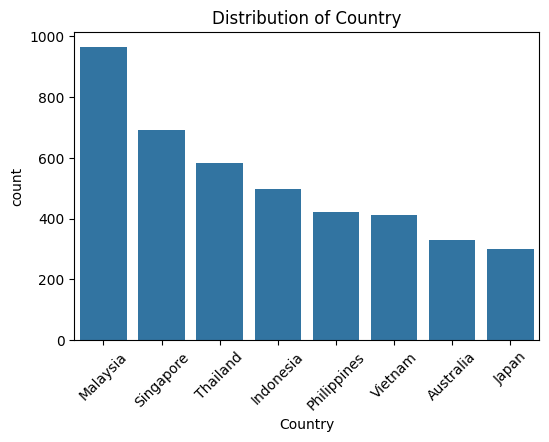

Country
Malaysia       23.000000
Singapore      16.476190
Thailand       13.880952
Indonesia      11.809524
Philippines    10.023810
Vietnam         9.833333
Australia       7.857143
Japan           7.119048
Name: proportion, dtype: float64


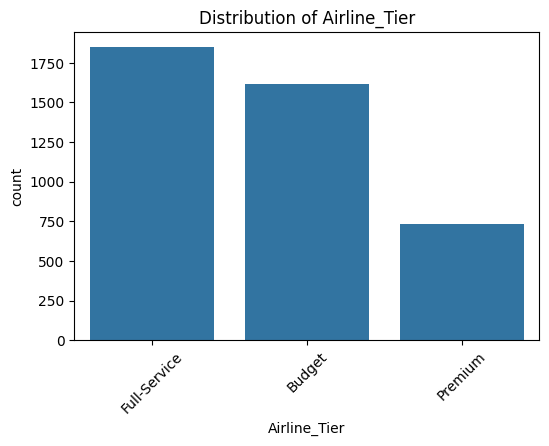

Airline_Tier
Full-Service    44.071429
Budget          38.452381
Premium         17.476190
Name: proportion, dtype: float64


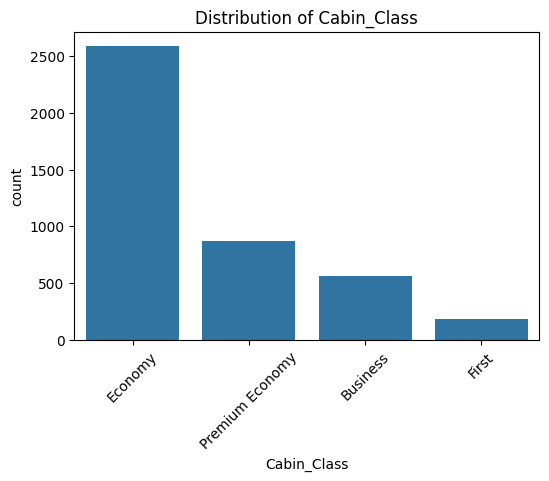

Cabin_Class
Economy            61.547619
Premium Economy    20.809524
Business           13.309524
First               4.333333
Name: proportion, dtype: float64


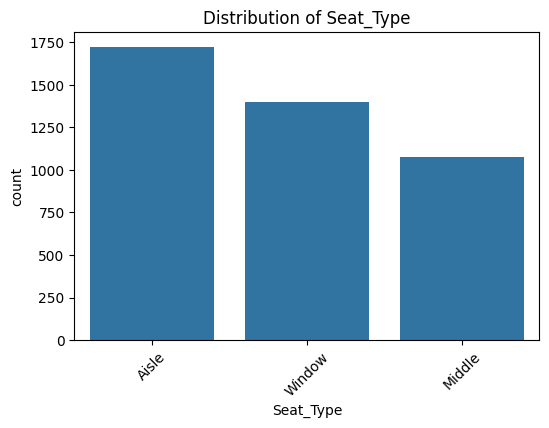

Seat_Type
Aisle     41.071429
Window    33.261905
Middle    25.666667
Name: proportion, dtype: float64


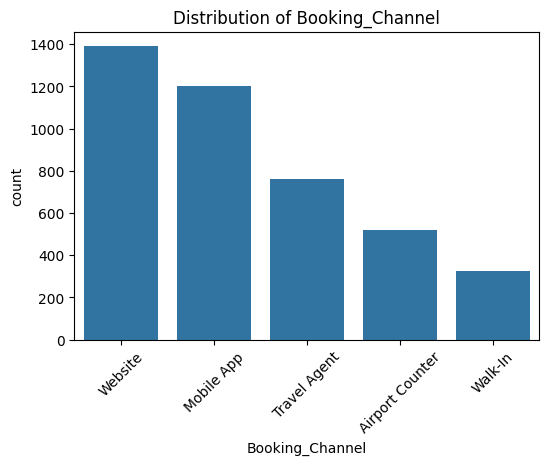

Booking_Channel
Website            33.095238
Mobile App         28.619048
Travel Agent       18.166667
Airport Counter    12.380952
Walk-In             7.738095
Name: proportion, dtype: float64


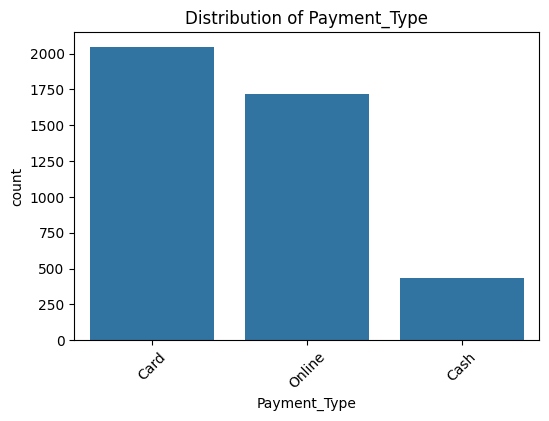

Payment_Type
Card      48.738095
Online    40.880952
Cash      10.380952
Name: proportion, dtype: float64


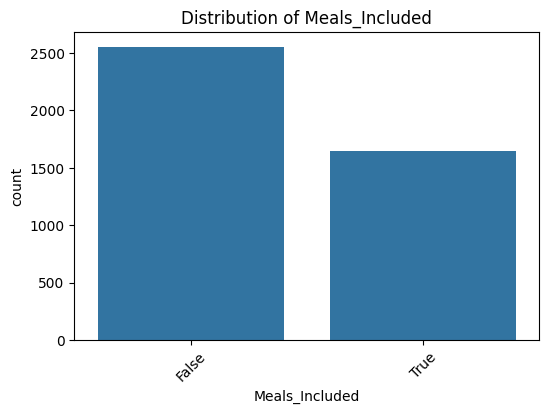

Meals_Included
False    60.857143
True     39.142857
Name: proportion, dtype: float64


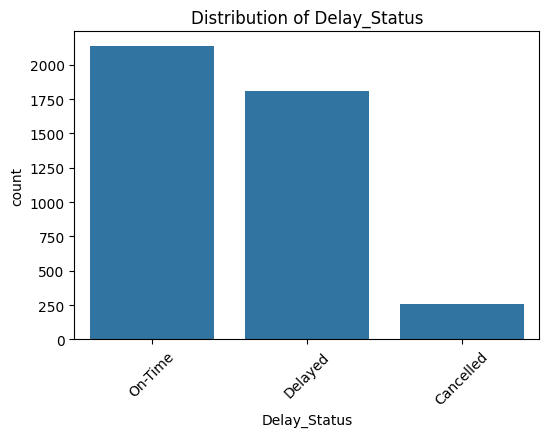

Delay_Status
On-Time      50.857143
Delayed      43.095238
Cancelled     6.047619
Name: proportion, dtype: float64


In [49]:
categorical_cols = [
    "Country",
    "Airline_Tier",
    "Cabin_Class",
    "Seat_Type",
    "Booking_Channel",
    "Payment_Type",
    "Meals_Included",
    "Delay_Status"
]


for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

    print(df[col].value_counts(normalize=True)*100)

Malaysia represents the largest proportion of bookings (23.0%), followed by Singapore (16.5%) and Thailand (13.9%). The remaining countries contribute relatively balanced proportions, indicating that the dataset covers a diverse range of travel markets within the Asia-Pacific region.

Full-service airlines account for the highest proportion of bookings (44.1%), followed by budget airlines (38.5%), while premium airlines represent the smallest share (17.5%). This distribution suggests that the dataset includes a balanced mix of airline service levels, with a slight emphasis on full-service carriers.

Economy class dominates the dataset, accounting for 61.5% of all bookings, whereas first-class bookings comprise only 4.3%. This distribution reflects typical airline travel patterns, where economy cabins serve the majority of passengers.

Aisle seats are the most frequently selected seat type (41.1%), followed by window seats (33.3%) and middle seats (25.7%). This suggests a slight passenger preference for aisle seating, likely due to greater accessibility and comfort.

Most bookings are made through the airline website (33.1%) and mobile application (28.6%), together accounting for more than 60% of all bookings. This indicates that digital platforms are the primary booking channels, while walk-in bookings remain relatively uncommon.

Card payments are the most commonly used payment method (48.7%), followed closely by online payments (40.9%), whereas cash payments account for only 10.4% of bookings. This suggests a strong preference for electronic payment methods among customers.

Approximately 60.9% of bookings do not include meals, while 39.1% include meal services. This suggests that meal packages are optional for many passengers and may represent an ancillary service rather than a standard offering.

Most flights are recorded as on-time (50.9%), while delayed flights account for 43.1% of the observations. Cancelled flights represent only 6.0% of the dataset, indicating that cancellations are relatively rare compared to on-time and delayed flights.

### Numerical Variable

In [50]:
numerical_cols = [
    "Passenger_Age",
    "Flight_Duration_Hours",
    "Lead_Time_Days",
    "Service_Rating",
    "Load_Factor_Flight",
    "Review_Score",
    "Competitor_Avg_Fare_RM",
    "Distance_KM",
    "Ticket_Price_RM",
    "Total_Spend_RM",
    "Extra_Spend_Unscaled"
]

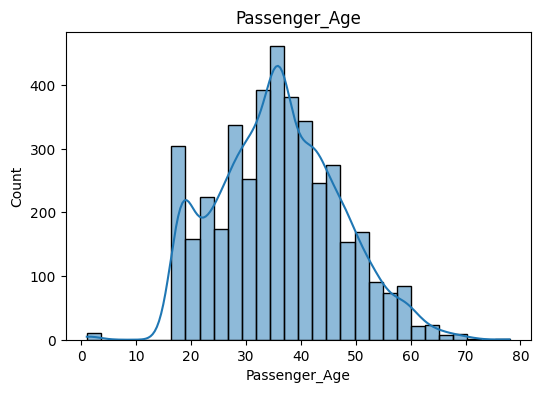

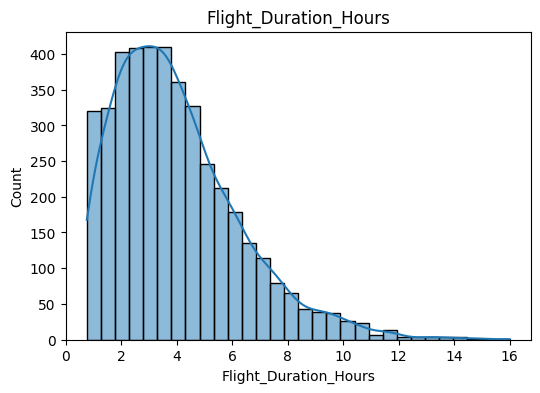

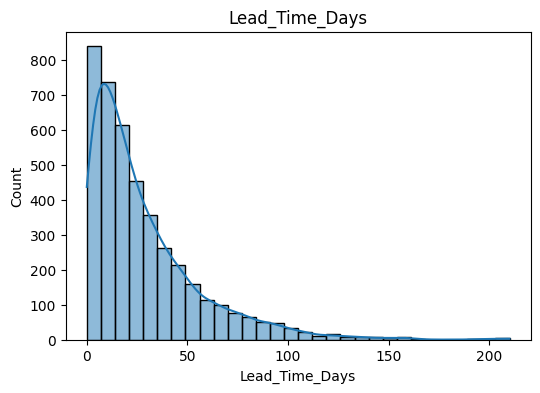

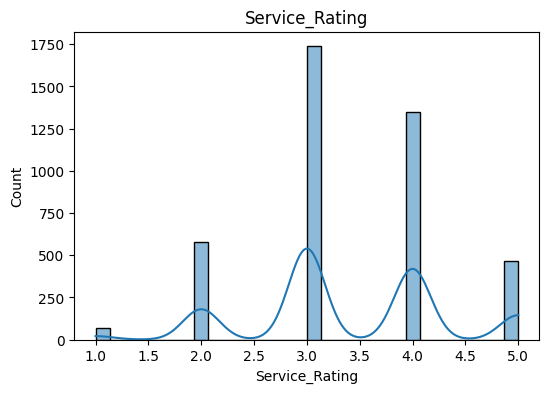

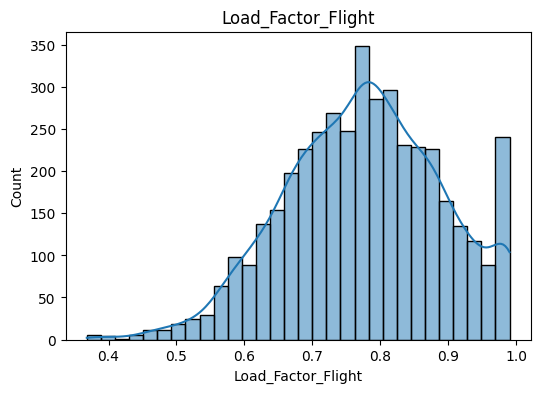

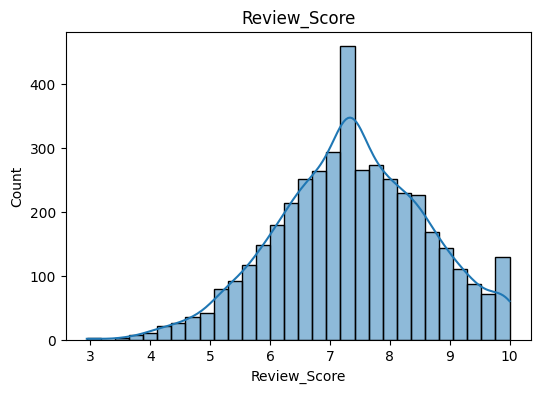

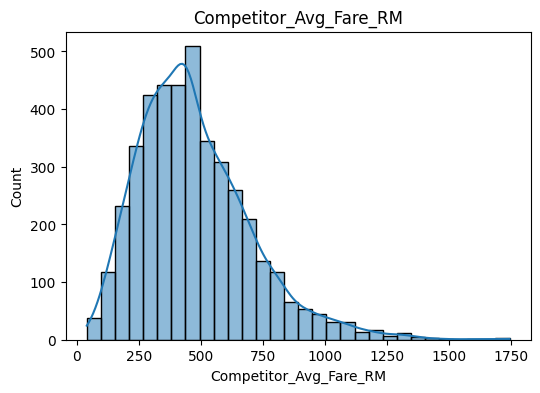

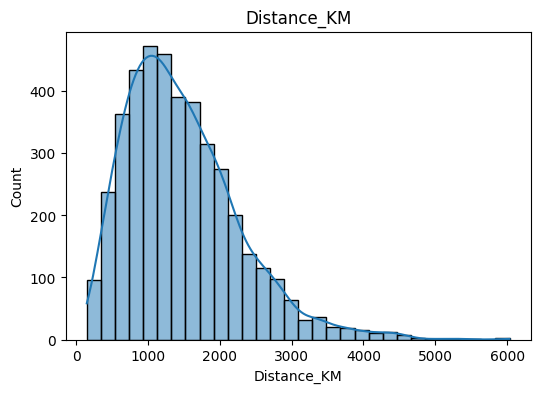

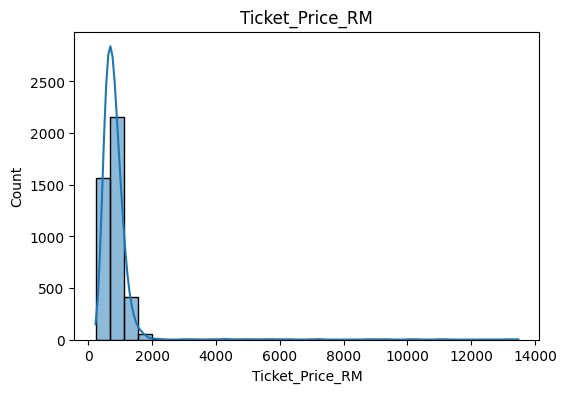

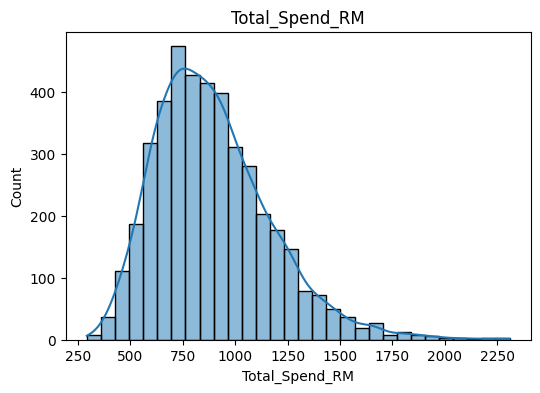

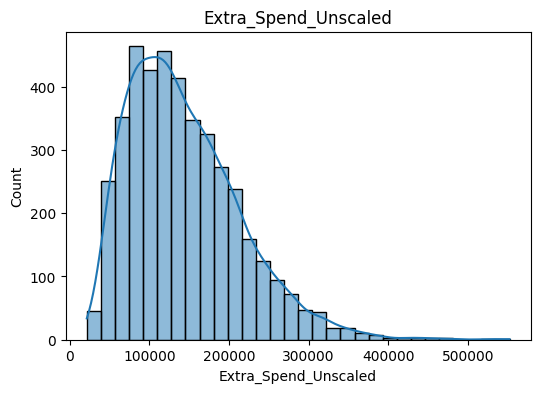

In [51]:
#histogram
for col in numerical_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
    plt.show()

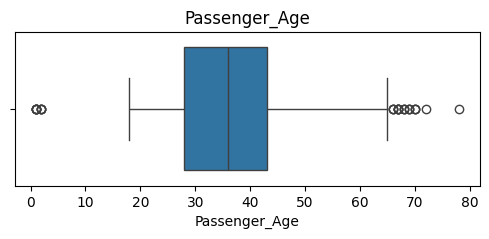

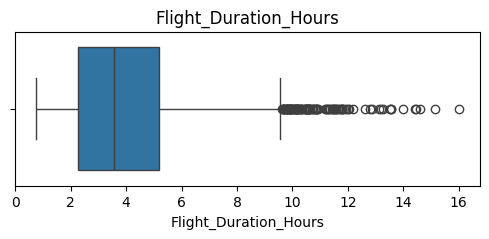

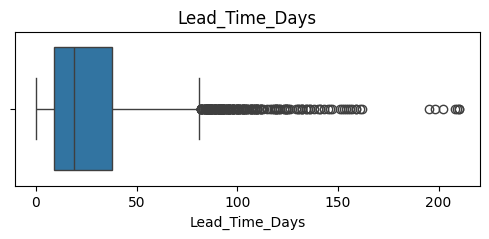

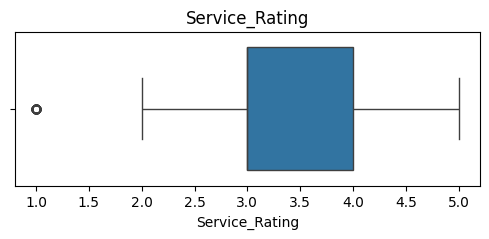

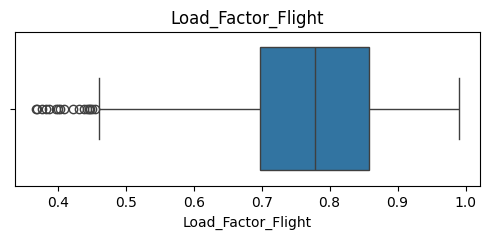

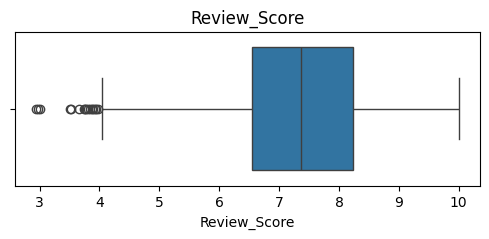

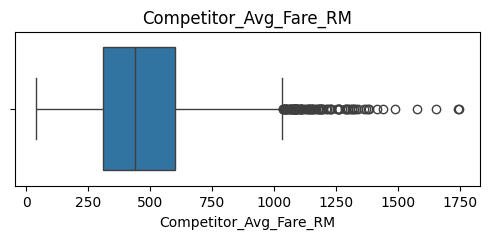

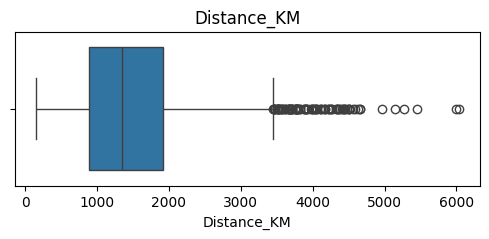

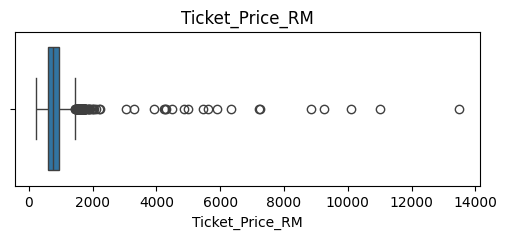

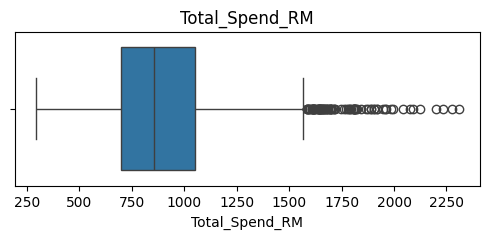

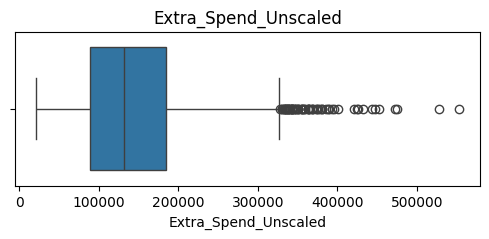

In [52]:
#boxplot
for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [53]:
#summary statistics
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Passenger_Age,4200.0,35.957857,11.008792,1.000,28.0000,36.000,43.0000,78.000000
Flight_Duration_Hours,4200.0,3.979055,2.274313,0.750,2.2800,3.580,5.2000,16.000000
Lead_Time_Days,4200.0,27.866905,27.419981,0.000,9.0000,19.000,38.0000,210.000000
Service_Rating,4200.0,3.374286,0.909009,1.000,3.0000,3.000,4.0000,5.000000
Load_Factor_Flight,4200.0,0.776132,0.115233,0.368,0.6970,0.778,0.8580,0.990000
Review_Score,4200.0,7.368879,1.253513,2.940,6.5500,7.360,8.2400,10.000000
Competitor_Avg_Fare_RM,4200.0,474.289776,227.297309,40.000,311.5425,439.630,600.2925,1745.770000
Distance_KM,4200.0,1478.403310,792.454044,150.000,892.8750,1345.450,1915.5250,6032.800000
Ticket_Price_RM,4200.0,809.474410,504.974283,223.000,590.1100,749.045,936.9425,13477.784407
Total_Spend_RM,4200.0,892.896281,274.996859,292.570,696.2325,854.970,1051.0100,2308.320000


In [54]:
#skewness
df[numerical_cols].skew()

,0
Passenger_Age,0.217304
Flight_Duration_Hours,1.071275
Lead_Time_Days,1.923275
Service_Rating,-0.045715
Load_Factor_Flight,-0.182083
Review_Score,-0.121430
Competitor_Avg_Fare_RM,1.003703
Distance_KM,1.078589
Ticket_Price_RM,11.992054
Total_Spend_RM,0.897082


| Variable                   | Distribution                    | Outliers    | Interpretation                                                                                                                                                       |
| -------------------------- | ------------------------------- | ----------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Passenger_Age**          | Slightly right-skewed (0.22)    | Few         | Passenger ages are centred around 36 years, with most passengers between 28 and 43 years old. The distribution is fairly symmetric with only a slight positive skew. |
| **Flight_Duration_Hours**  | Moderately right-skewed (1.07)  | Present     | Most flights are relatively short, with a median duration of 3.58 hours, while a few long-haul flights extend up to 16 hours.                                        |
| **Lead_Time_Days**         | Strongly right-skewed (1.92)    | Present     | Most customers book within 38 days before departure, although a small number book several months in advance (up to 210 days).                                        |
| **Service_Rating**         | Approximately symmetric (-0.05) | None        | Customer service ratings are concentrated around 3–4, indicating generally average service quality across airlines.                                                  |
| **Load_Factor_Flight**     | Approximately symmetric (-0.18) | Few         | Flight occupancy levels are consistently high, with most flights operating between 70% and 86% capacity.                                                             |
| **Review_Score**           | Approximately symmetric (-0.12) | Few         | Review scores are centred around 7.4 out of 10, suggesting generally positive customer satisfaction.                                                                 |
| **Competitor_Avg_Fare_RM** | Moderately right-skewed (1.00)  | Present     | Competitor fares are mostly below RM600, although several premium routes have considerably higher fares.                                                             |
| **Distance_KM**            | Moderately right-skewed (1.08)  | Present     | Most flights are short- to medium-haul, while relatively few long-distance flights exceed 6,000 km.                                                                  |
| **Ticket_Price_RM**        | Extremely right-skewed (11.99)  | Significant | Ticket prices are concentrated below RM1,000, with several extreme high-priced observations creating a long right tail.                                              |
| **Total_Spend_RM**         | Slightly right-skewed (0.90)    | Few         | Total passenger spending is generally concentrated around RM855, with moderate variation due to additional purchases.                                                |
| **Extra_Spend_Unscaled**   | Slightly right-skewed (0.94)    | Present     | Ancillary spending varies substantially across passengers, with a small number spending considerably more than the majority.                                         |


Most numerical variables exhibit either approximately symmetric or moderately right-skewed distributions, indicating that the majority of observations are concentrated within typical operating ranges while a small proportion of higher values create longer right tails. Variables such as Ticket_Price_RM, Lead_Time_Days, Distance_KM, and Flight_Duration_Hours contain noticeable outliers, which are expected in airline booking data due to premium fares, advance bookings, long-haul routes, and extended flight durations. Among all variables, Ticket_Price_RM shows the strongest positive skewness (11.99), reflecting the presence of a small number of exceptionally expensive tickets.

## Bivariate EDA

### Factors Affecting Ticket Price (Regression)

#### Categorical vs Ticket Price


--- Ticket Price (RM) statistics for Airline_Tier ---


,mean,median
Airline_Tier,,
Budget,814.027884,740.600
Full-Service,799.328487,746.810
Premium,825.041497,775.705


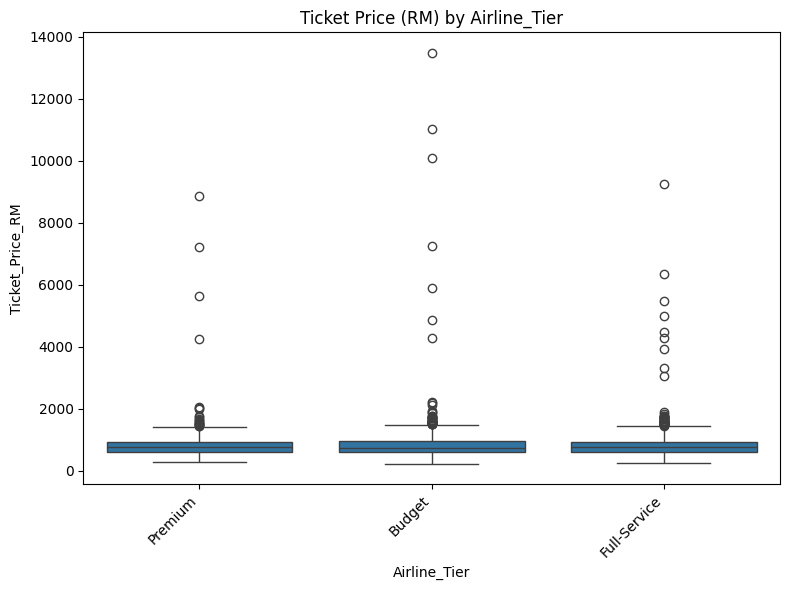


--- Ticket Price (RM) statistics for Cabin_Class ---


,mean,median
Cabin_Class,,
Business,923.075539,860.890
Economy,751.656262,693.940
First,1028.780129,961.985
Premium Economy,862.155462,782.720


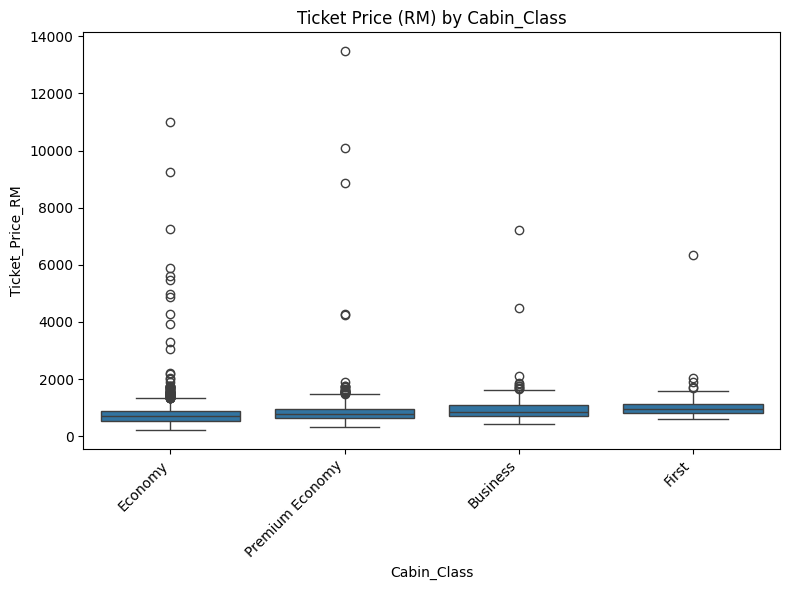


--- Ticket Price (RM) statistics for Seat_Type ---


,mean,median
Seat_Type,,
Aisle,796.720245,751.76
Middle,795.777929,737.23
Window,835.792048,752.34


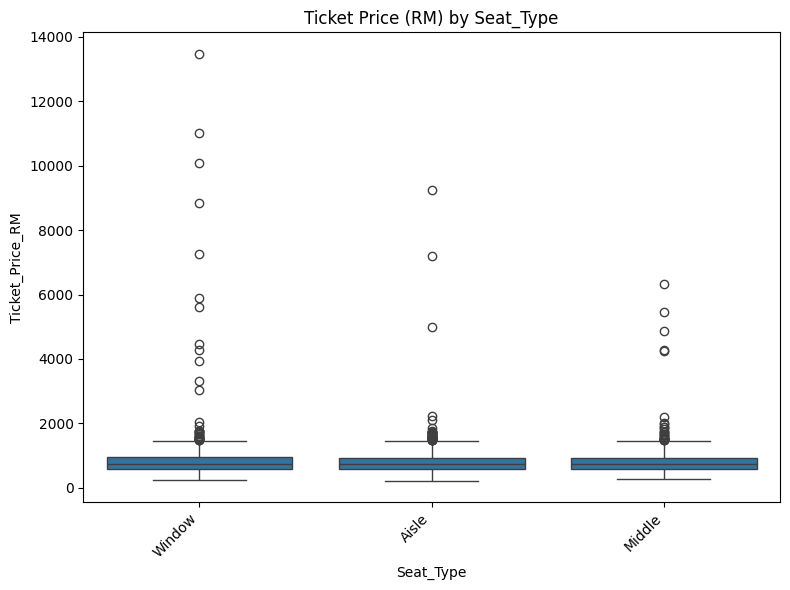


--- Ticket Price (RM) statistics for Booking_Channel ---


,mean,median
Booking_Channel,,
Airport Counter,815.817834,762.905
Mobile App,812.839125,750.930
Travel Agent,793.782040,736.750
Walk-In,795.133925,752.930
Website,816.158559,744.535


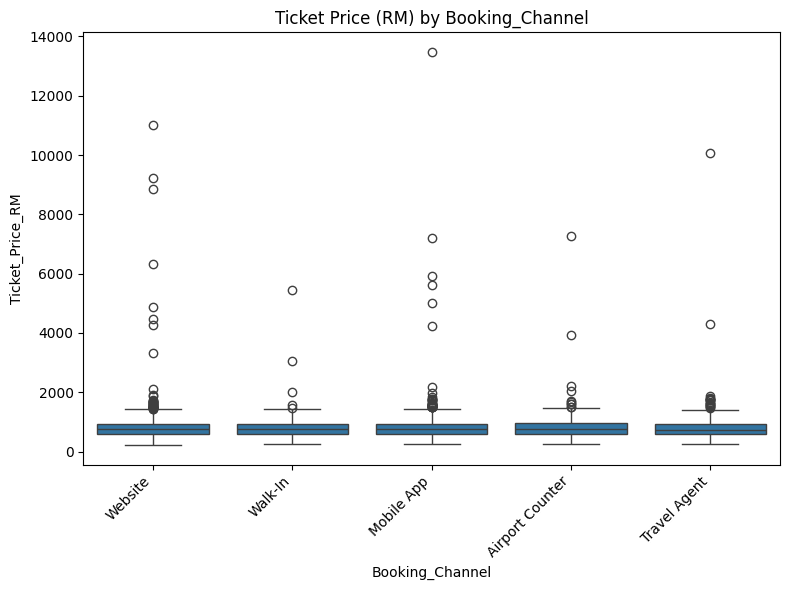


--- Ticket Price (RM) statistics for Booking_Urgency ---


,mean,median
Booking_Urgency,,
Advance,794.203092,738.230
Early Bird,762.258193,719.675
Last Minute,820.980585,755.850
Short Notice,818.027657,756.605


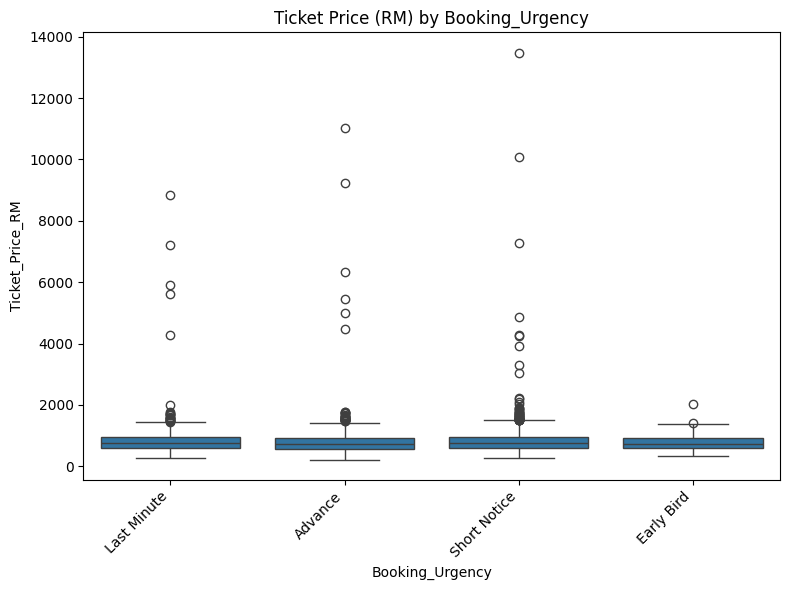


--- Ticket Price (RM) statistics for Peak_Travel ---


,mean,median
Peak_Travel,,
Public Holiday,804.242019,749.48
Regular Day,813.513674,751.12
Weekend,802.949247,744.34
Weekend & Holiday,798.743814,727.70


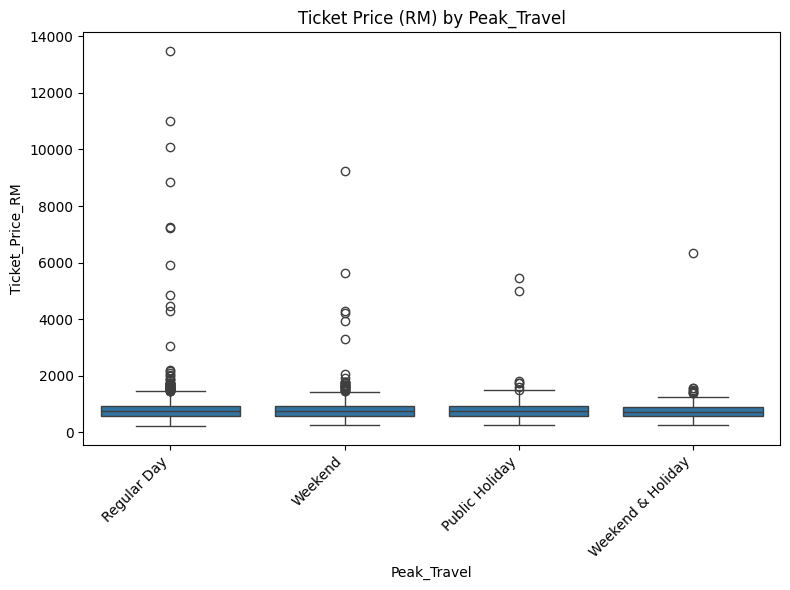

In [55]:
categorical_price_analysis = [
    "Airline_Tier",
    "Cabin_Class",
    "Seat_Type",
    "Booking_Channel",
    "Booking_Urgency",
    "Peak_Travel"
]

for col in categorical_price_analysis:
    print(f"\n--- Ticket Price (RM) statistics for {col} ---")

    # Display mean and median ticket prices for each category
    price_stats = df.groupby(col)['Ticket_Price_RM'].agg(['mean', 'median'])
    display(price_stats)

    plt.figure(figsize=(8, 6))
    sns.boxplot(
        data=df,
        x=col,
        y="Ticket_Price_RM"
    )
    plt.title(f'Ticket Price (RM) by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

Airline Tier

Ticket prices are relatively similar across airline tiers, although Premium airlines record the highest average ticket price (RM825.04) and median price (RM775.71). Budget and Full-Service airlines have comparable average prices of RM814.03 and RM799.33, respectively. The relatively small differences suggest that airline tier alone has only a limited influence on ticket price in this dataset.

Cabin Class

Cabin class demonstrates the clearest relationship with ticket price. Average ticket prices increase progressively from Economy (RM751.66) to Premium Economy (RM862.16), Business (RM923.08), and First Class (RM1,028.78). The median ticket prices follow the same pattern, increasing from RM693.94 for Economy to RM961.99 for First Class. This indicates that higher cabin classes are consistently associated with higher ticket prices.

Booking Channel

Average ticket prices are relatively consistent across booking channels, ranging from RM793.78 for Travel Agent bookings to RM816.16 for Website bookings. Median ticket prices also differ only marginally, indicating that the booking platform has little impact on ticket prices in this dataset.

Booking Urgency

Booking urgency exhibits a noticeable relationship with ticket price. Last Minute (RM820.98) and Short Notice (RM818.03) bookings have the highest average ticket prices, whereas Early Bird bookings have the lowest average price (RM762.26). Median ticket prices follow a similar trend, increasing from RM719.68 for Early Bird bookings to approximately RM756 for Last Minute and Short Notice bookings. This suggests that passengers booking closer to the departure date generally pay higher fares.

Peak Travel

Ticket prices remain relatively stable across different travel periods. Average ticket prices range narrowly between RM798.74 and RM813.51, while median prices differ by less than RM25. These small differences indicate that peak travel periods alone do not substantially influence ticket prices within this dataset.

Among the categorical variables analysed, Cabin Class and Booking Urgency exhibit the strongest relationships with ticket price. Higher cabin classes consistently command higher average and median fares, while bookings made closer to the departure date generally incur higher ticket prices than advance bookings. In contrast, Airline Tier, Seat Type, Booking Channel, and Peak Travel show relatively small differences in average and median ticket prices, suggesting that these variables have weaker individual associations with ticket pricing.

#### Numerical vs Ticket Price

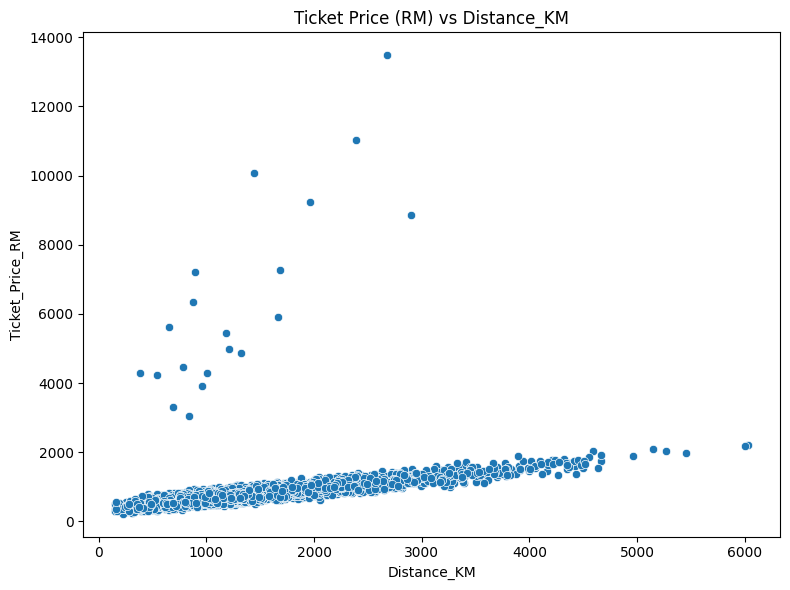

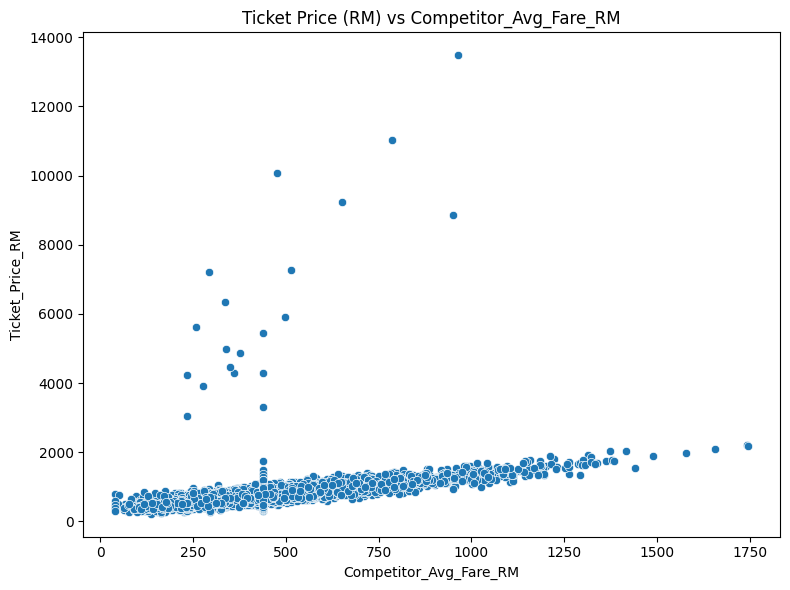

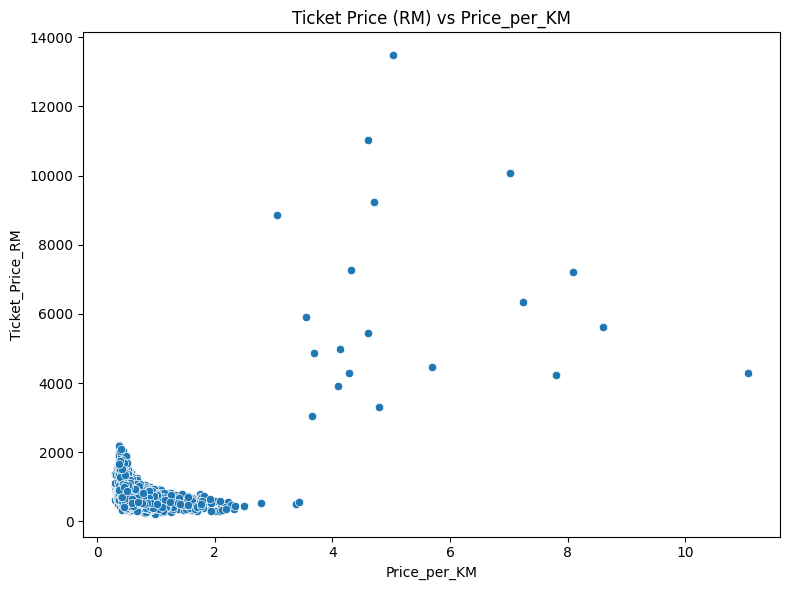

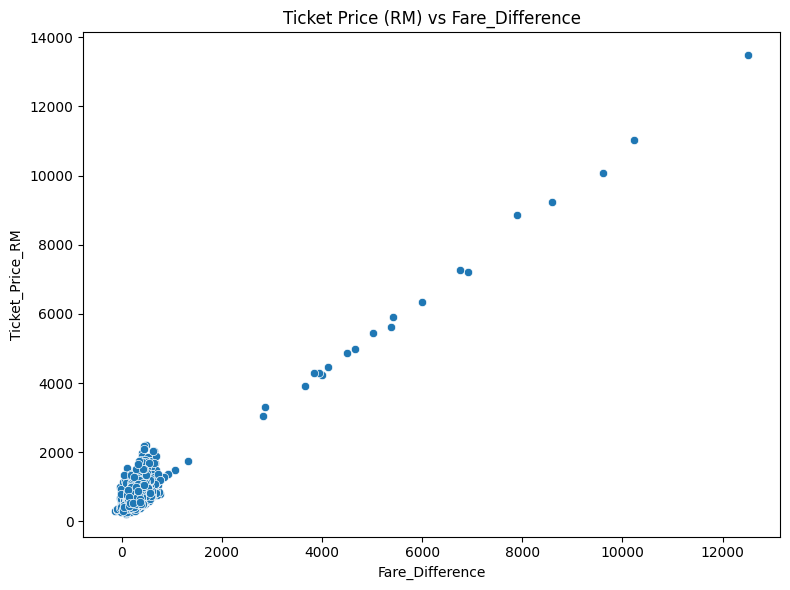

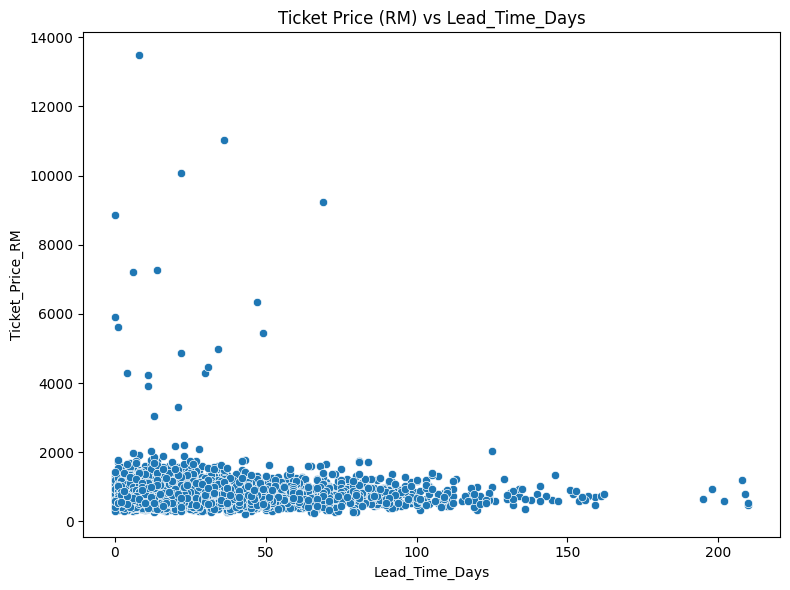

In [56]:
numerical_price_analysis = [
    "Distance_KM",
    "Competitor_Avg_Fare_RM",
    "Price_per_KM",
    "Fare_Difference",
    "Lead_Time_Days"
]

for col in numerical_price_analysis:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=df,
        x=col,
        y="Ticket_Price_RM"
    )
    plt.title(f'Ticket Price (RM) vs {col}')
    plt.xlabel(col)
    plt.ylabel('Ticket_Price_RM')
    plt.tight_layout()
    plt.show()

**Distance (Distance_KM)**

Ticket price generally increases as flight distance increases, indicating a moderate positive relationship between the two variables. Although several high-priced outliers are observed, the overall upward trend suggests that longer travel distances are associated with higher ticket prices.

**Competitor Average Fare (Competitor_Avg_Fare_RM)**

Ticket prices exhibit a clear positive relationship with competitor average fares. As competitor fares increase, ticket prices also tend to rise, suggesting that airlines adjust their pricing in response to market conditions and competing fares.

**Price per KM**

A concentration of observations is found at lower price-per-kilometre values, while several extreme observations exhibit substantially higher prices per kilometre. These cases correspond to unusually expensive tickets relative to the travel distance and were retained as part of the dataset after data validation.

**Fare Difference**

A strong linear relationship is observed because Fare Difference is directly derived from the difference between the airline ticket price and the competitor's average fare. Therefore, this relationship is expected mathematically rather than representing an independent business effect.

**Lead Time**

No strong linear relationship is observed between booking lead time and ticket price. However, higher-priced tickets appear more frequently among bookings made closer to the departure date, whereas customers booking well in advance generally experience lower and less variable ticket prices.

### Factors Associated with Flight Delay (Classification)


#### Categorical Variable


--- Delay Status distribution for Country ---


Delay_Status,Cancelled,Delayed,On-Time
Country,,,
Australia,18,153,159
Indonesia,30,221,245
Japan,22,128,149
Malaysia,65,399,502
Philippines,18,180,223
Singapore,50,294,348
Thailand,34,253,296
Vietnam,17,182,214


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Country,,,
Australia,5.454545,46.363636,48.181818
Indonesia,6.048387,44.556452,49.395161
Japan,7.357860,42.809365,49.832776
Malaysia,6.728778,41.304348,51.966874
Philippines,4.275534,42.755344,52.969121
Singapore,7.225434,42.485549,50.289017
Thailand,5.831904,43.396226,50.771870
Vietnam,4.116223,44.067797,51.815981


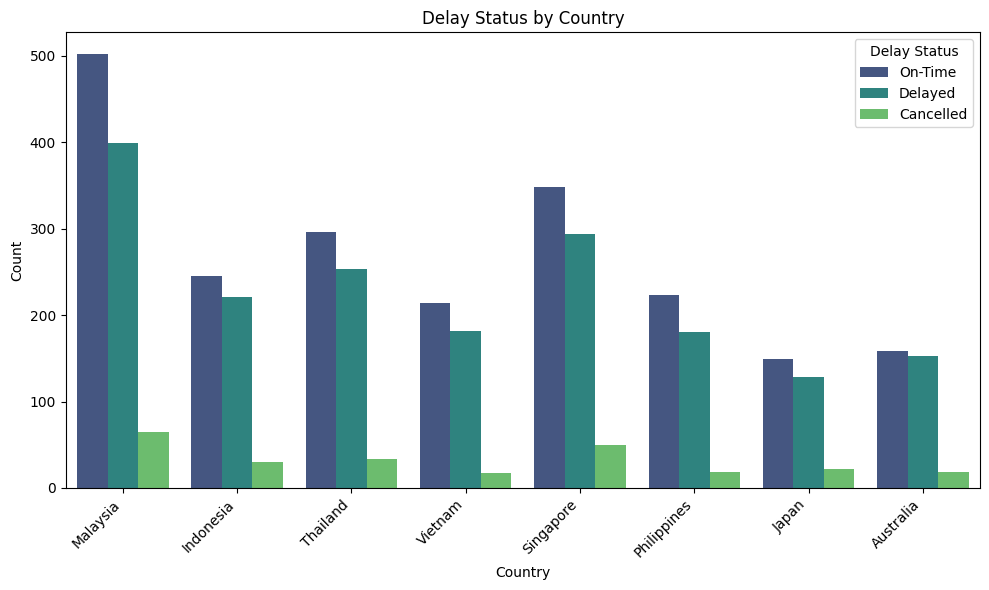


--- Delay Status distribution for Airline_Tier ---


Delay_Status,Cancelled,Delayed,On-Time
Airline_Tier,,,
Budget,135,813,667
Full-Service,88,719,1044
Premium,31,278,425


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Airline_Tier,,,
Budget,8.359133,50.340557,41.300310
Full-Service,4.754187,38.843868,56.401945
Premium,4.223433,37.874659,57.901907


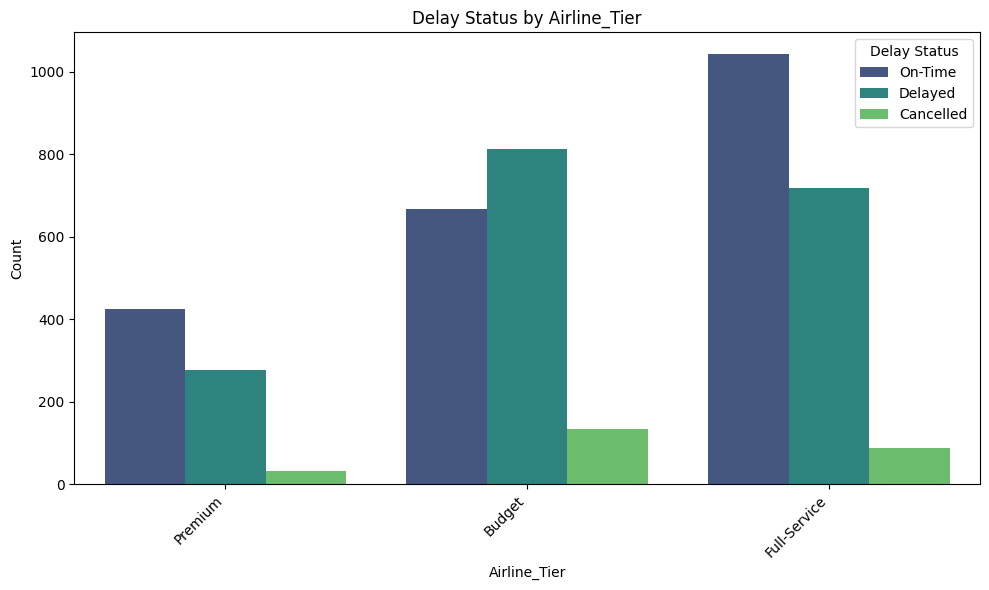


--- Delay Status distribution for Cabin_Class ---


Delay_Status,Cancelled,Delayed,On-Time
Cabin_Class,,,
Business,43,214,302
Economy,161,1149,1275
First,11,66,105
Premium Economy,39,381,454


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Cabin_Class,,,
Business,7.692308,38.282648,54.025045
Economy,6.228240,44.448743,49.323017
First,6.043956,36.263736,57.692308
Premium Economy,4.462243,43.592677,51.945080


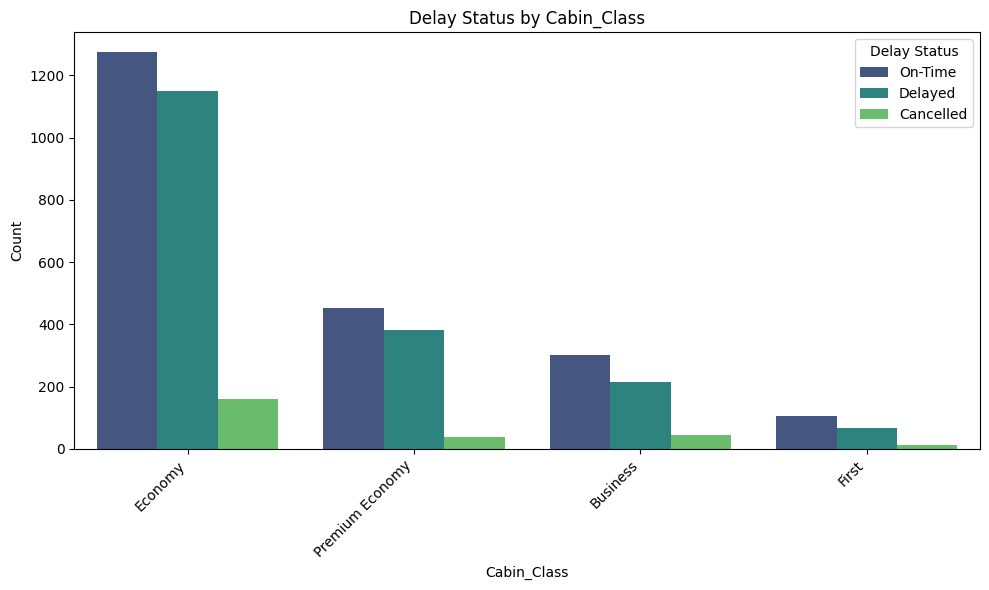


--- Delay Status distribution for Seat_Type ---


Delay_Status,Cancelled,Delayed,On-Time
Seat_Type,,,
Aisle,92,754,879
Middle,65,462,551
Window,97,594,706


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Seat_Type,,,
Aisle,5.333333,43.710145,50.956522
Middle,6.029685,42.857143,51.113173
Window,6.943450,42.519685,50.536865


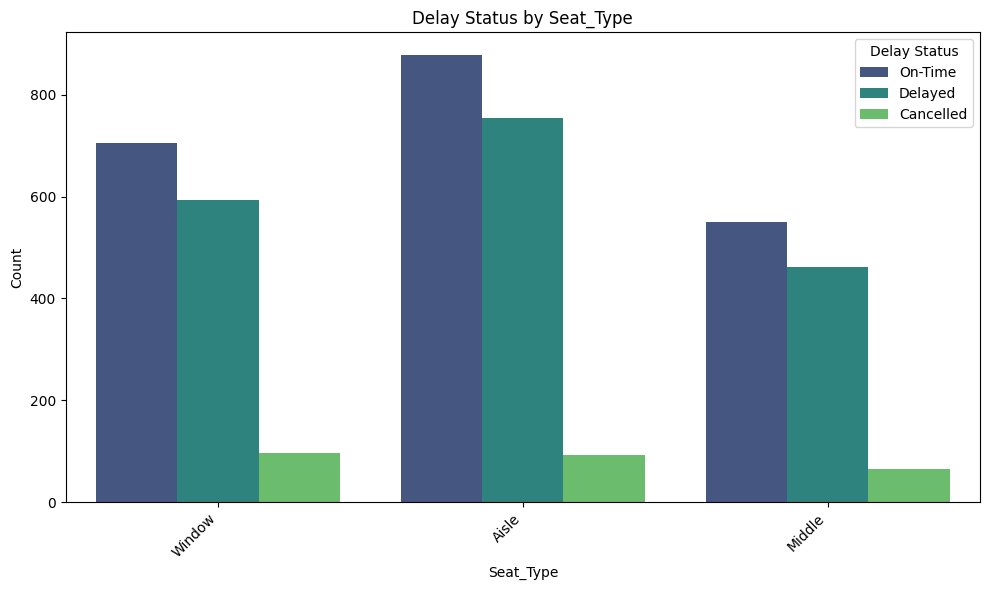


--- Delay Status distribution for Booking_Channel ---


Delay_Status,Cancelled,Delayed,On-Time
Booking_Channel,,,
Airport Counter,27,219,274
Mobile App,80,539,583
Travel Agent,36,327,400
Walk-In,22,127,176
Website,89,598,703


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Booking_Channel,,,
Airport Counter,5.192308,42.115385,52.692308
Mobile App,6.655574,44.841930,48.502496
Travel Agent,4.718218,42.857143,52.424640
Walk-In,6.769231,39.076923,54.153846
Website,6.402878,43.021583,50.575540


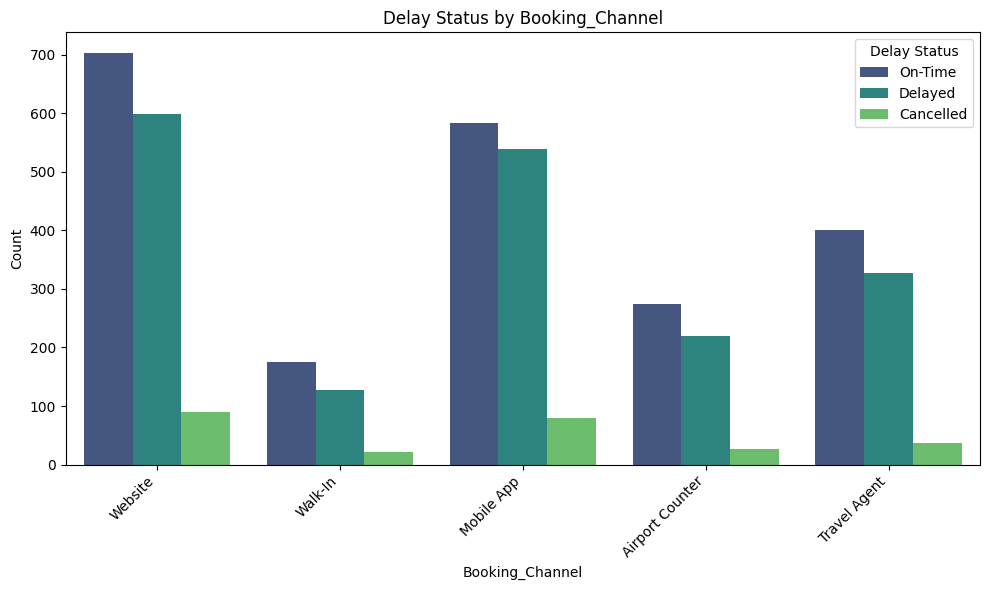


--- Delay Status distribution for Payment_Type ---


Delay_Status,Cancelled,Delayed,On-Time
Payment_Type,,,
Card,135,858,1054
Cash,29,190,217
Online,90,762,865


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Payment_Type,,,
Card,6.595017,41.914998,51.489985
Cash,6.651376,43.577982,49.770642
Online,5.241701,44.379732,50.378567


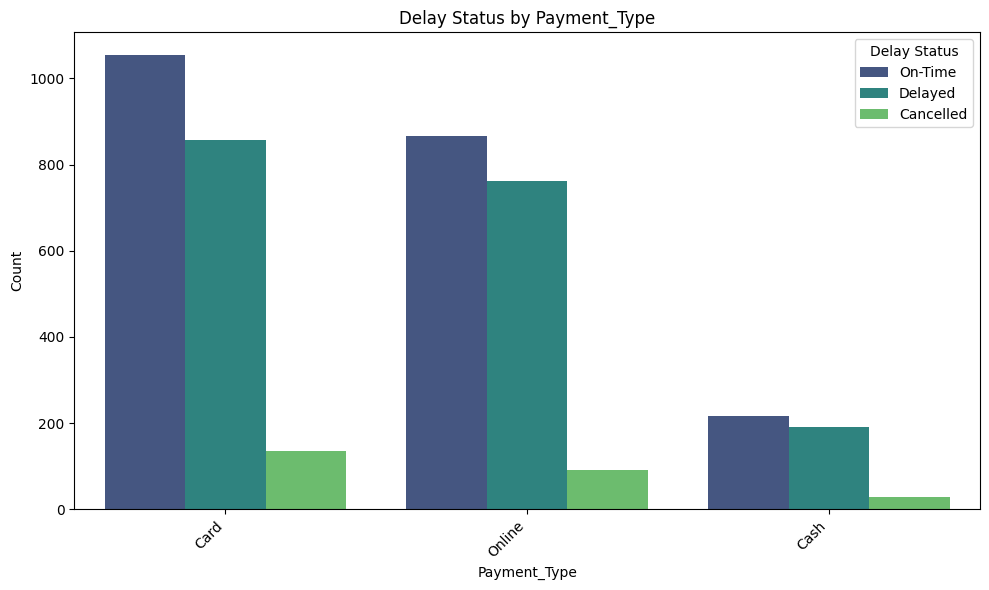


--- Delay Status distribution for Meals_Included ---


Delay_Status,Cancelled,Delayed,On-Time
Meals_Included,,,
False,164,1088,1304
True,90,722,832


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Meals_Included,,,
False,6.416275,42.566510,51.017214
True,5.474453,43.917275,50.608273


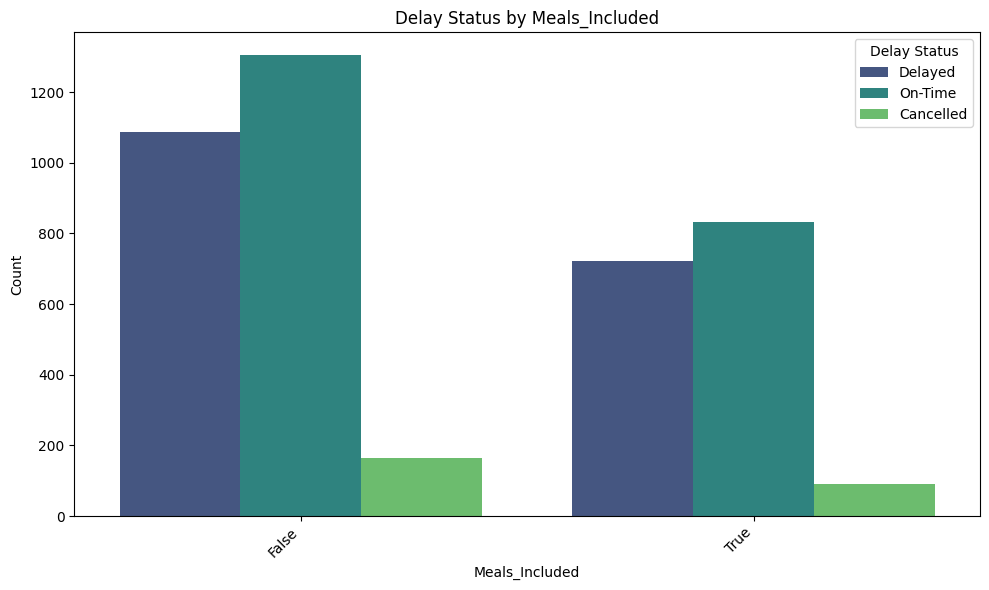


--- Delay Status distribution for Day_of_Week ---


Delay_Status,Cancelled,Delayed,On-Time
Day_of_Week,,,
Friday,30,234,313
Monday,24,234,328
Saturday,48,309,249
Sunday,48,296,279
Thursday,29,250,326
Tuesday,38,244,311
Wednesday,37,243,330


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Day_of_Week,,,
Friday,5.199307,40.554593,54.246101
Monday,4.095563,39.931741,55.972696
Saturday,7.920792,50.990099,41.089109
Sunday,7.704655,47.512039,44.783307
Thursday,4.793388,41.322314,53.884298
Tuesday,6.408094,41.146712,52.445194
Wednesday,6.065574,39.836066,54.098361


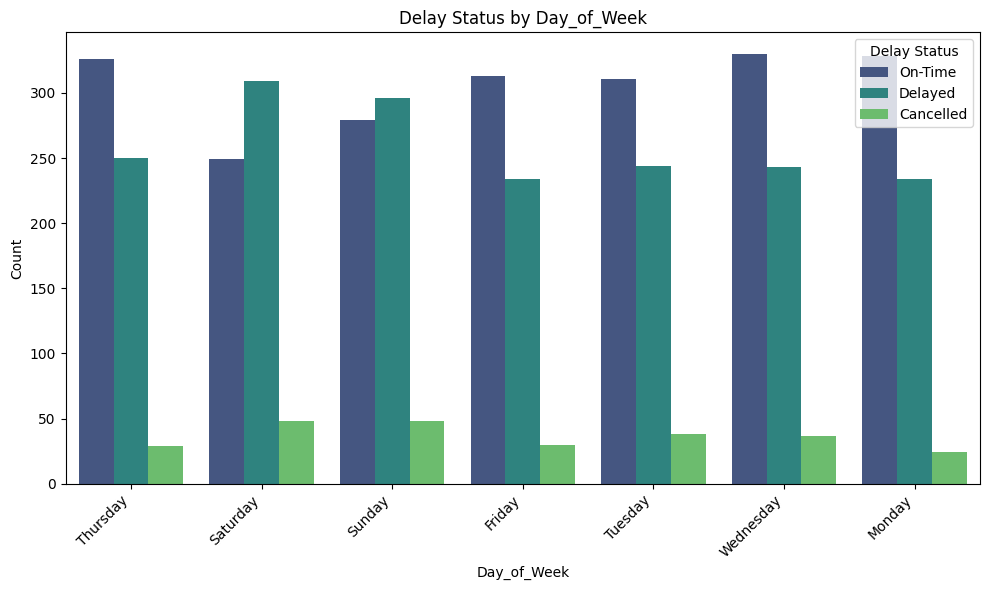


--- Delay Status distribution for Booking_Urgency ---


Delay_Status,Cancelled,Delayed,On-Time
Booking_Urgency,,,
Advance,70,529,639
Early Bird,8,74,84
Last Minute,68,404,486
Short Notice,108,803,927


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Booking_Urgency,,,
Advance,5.654281,42.730210,51.615509
Early Bird,4.819277,44.578313,50.602410
Last Minute,7.098121,42.171190,50.730689
Short Notice,5.875952,43.688792,50.435256


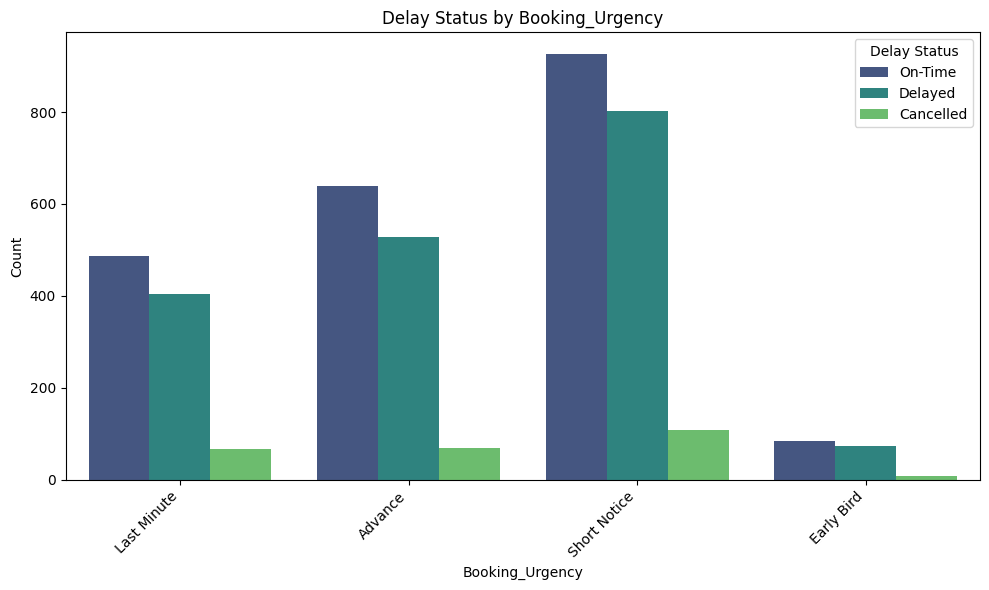


--- Delay Status distribution for Peak_Travel ---


Delay_Status,Cancelled,Delayed,On-Time
Peak_Travel,,,
Public Holiday,29,221,110
Regular Day,129,984,1498
Weekend,75,501,500
Weekend & Holiday,21,104,28


Percentage distribution:


Delay_Status,Cancelled,Delayed,On-Time
Peak_Travel,,,
Public Holiday,8.055556,61.388889,30.555556
Regular Day,4.940636,37.686710,57.372654
Weekend,6.970260,46.561338,46.468401
Weekend & Holiday,13.725490,67.973856,18.300654


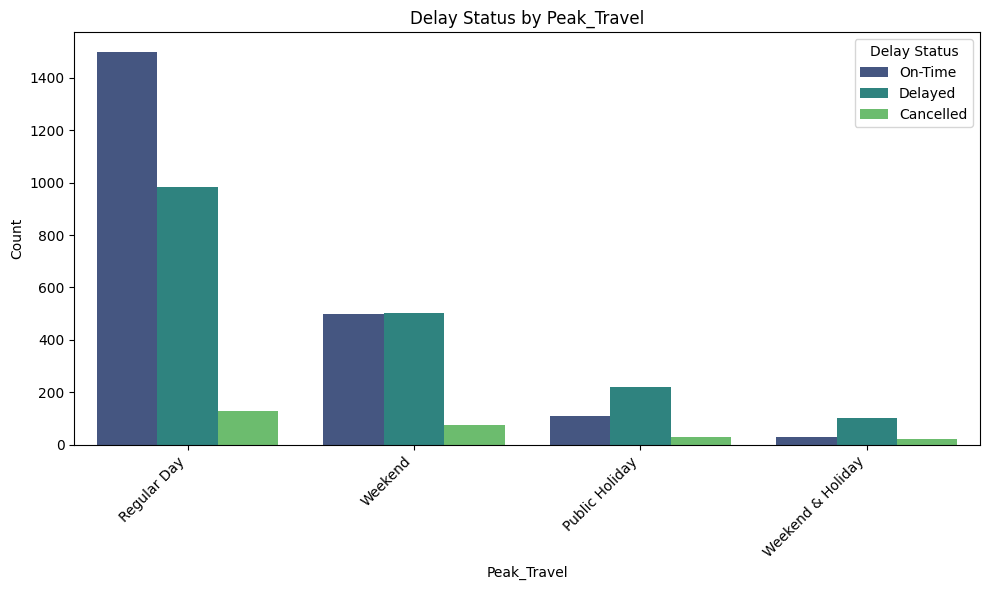

In [57]:
categorical_delay_analysis = [
    "Country",
    "Airline_Tier",
    "Cabin_Class",
    "Seat_Type",
    "Booking_Channel",
    "Payment_Type",
    "Meals_Included",
    "Day_of_Week",
    "Booking_Urgency",
    "Peak_Travel"
]

for col in categorical_delay_analysis:
    print(f"\n--- Delay Status distribution for {col} ---")

    # Display raw counts
    crosstab_counts = pd.crosstab(df[col], df['Delay_Status'])
    display(crosstab_counts)

    # Display percentages
    crosstab_percent = pd.crosstab(df[col], df['Delay_Status'], normalize='index') * 100
    print("Percentage distribution:")
    display(crosstab_percent)

    plt.figure(figsize=(10, 6))
    sns.countplot(
        data=df,
        x=col,
        hue="Delay_Status",
        palette="viridis"
    )
    plt.title(f'Delay Status by {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Delay Status')
    plt.tight_layout()
    plt.show()

Country

The distribution of flight delay status is relatively consistent across all countries. On-time flights range from 48.18% (Australia) to 52.97% (Philippines), while delayed flights vary only between 41.30% (Malaysia) and 46.36% (Australia). Cancellation rates are also fairly similar, ranging from 4.12% (Vietnam) to 7.36% (Japan). These small differences suggest that passengers' country of departure is not strongly associated with flight delay outcomes in this dataset.

Airline Tier

Airline tier exhibits one of the strongest associations with flight delay status. Budget airlines recorded the highest proportion of delayed flights (50.34%) and the lowest proportion of on-time flights (41.30%). In contrast, Premium airlines achieved the highest on-time rate (57.90%) and the lowest delay rate (37.87%), followed closely by Full-Service airlines (56.40% on-time; 38.84% delayed). Budget airlines also experienced the highest cancellation rate (8.36%), almost double that of Premium airlines (4.22%). These findings suggest that higher-tier airlines generally demonstrate better operational reliability.

Cabin Class

Cabin class shows moderate differences in flight delay outcomes. First Class passengers experienced the highest proportion of on-time flights (57.69%) and the lowest delay rate (36.26%), while Economy Class recorded the highest delay rate (44.45%) and the lowest on-time proportion (49.32%). Premium Economy and Business Class fall between these extremes. Although differences are smaller than those observed for airline tier, premium cabins generally appear to be associated with better flight punctuality.


Booking Channel

Booking channel demonstrates only modest differences. Walk-in bookings have the highest proportion of on-time flights (54.15%) and the lowest delay rate (39.08%), whereas Mobile App bookings show the highest delay rate (44.84%) and the lowest on-time proportion (48.50%). However, the differences across booking channels remain relatively small, suggesting that booking method is only weakly associated with flight delay outcomes.



Day of Week

Day of the week displays a noticeable temporal pattern. Weekend flights experience poorer operational performance than weekdays. Saturday records the highest delay rate (50.99%) and one of the lowest on-time rates (41.09%), followed by Sunday (47.51% delayed; 44.78% on-time). In contrast, weekdays such as Monday (55.97% on-time) and Wednesday (54.10% on-time) show substantially better punctuality. These findings suggest increased passenger demand during weekends may contribute to more frequent delays.


Peak Travel

Peak travel period demonstrates the strongest relationship with flight delay status among all categorical variables. During Regular Days, over half of flights are on time (57.37%) and only 37.69% are delayed. However, during Public Holidays, delayed flights increase substantially to 61.39%, while on-time performance drops to 30.56%. The most severe operational disruption occurs during Weekend & Holiday periods, where 67.97% of flights are delayed, 13.73% are cancelled, and only 18.30% arrive on time. Weekend-only periods also show elevated delays (46.56%) compared with regular days. These results indicate that peak travel demand is strongly associated with reduced flight punctuality and increased operational disruptions.

#### Numerical Variable


--- Load_Factor_Flight statistics by Delay Status ---


,mean,median
Delay_Status,,
Cancelled,0.773512,0.7715
Delayed,0.779838,0.7810
On-Time,0.773303,0.7780


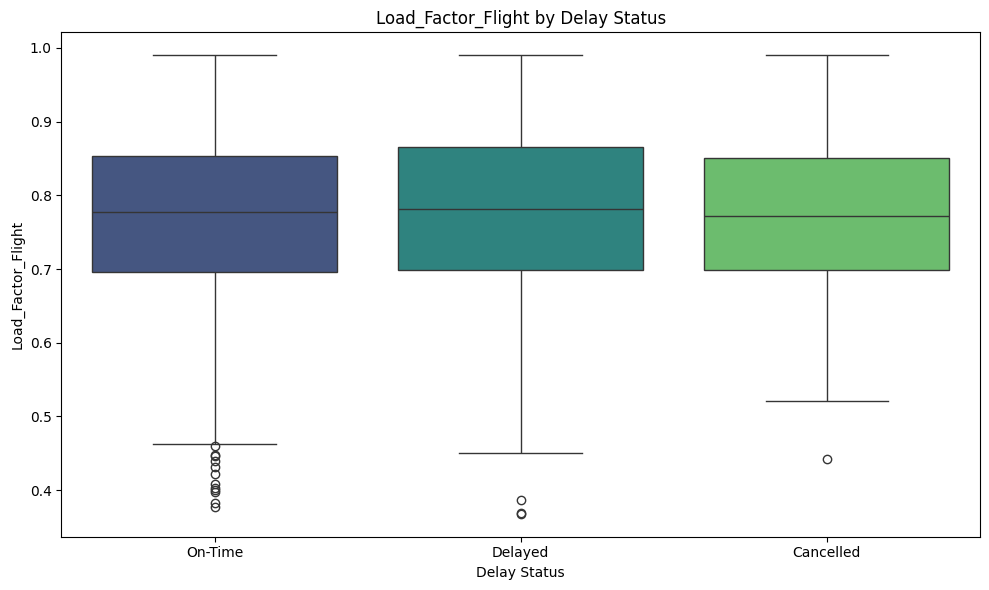


--- Flight_Duration_Hours statistics by Delay Status ---


,mean,median
Delay_Status,,
Cancelled,4.669528,4.25
Delayed,4.353790,3.92
On-Time,3.579405,3.28


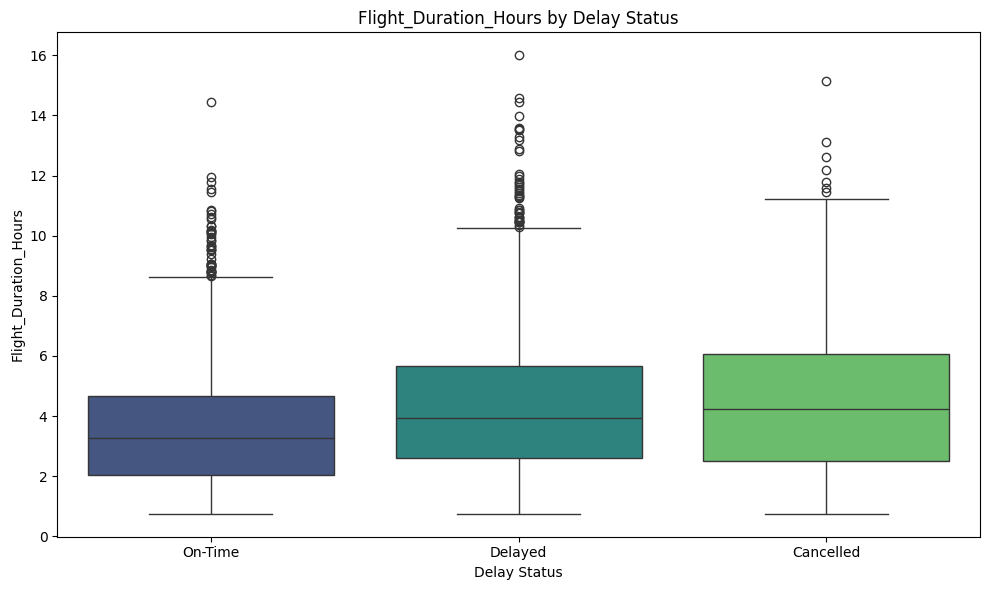


--- Service_Rating statistics by Delay Status ---


,mean,median
Delay_Status,,
Cancelled,3.275591,3.0
Delayed,3.391713,3.0
On-Time,3.371255,3.0


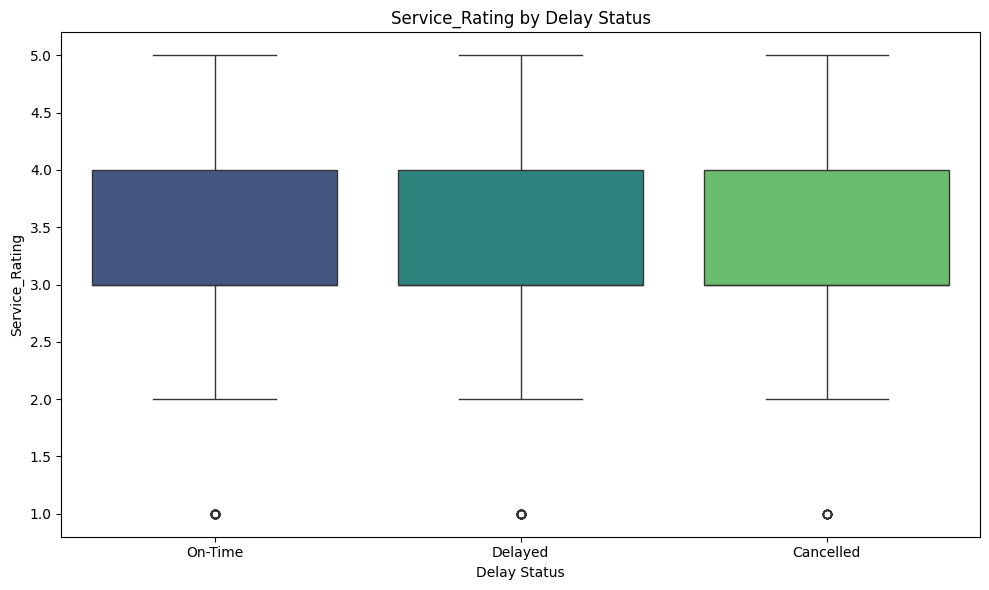


--- Distance_KM statistics by Delay Status ---


,mean,median
Delay_Status,,
Cancelled,1498.738976,1348.75
Delayed,1505.475470,1388.60
On-Time,1453.044757,1312.45


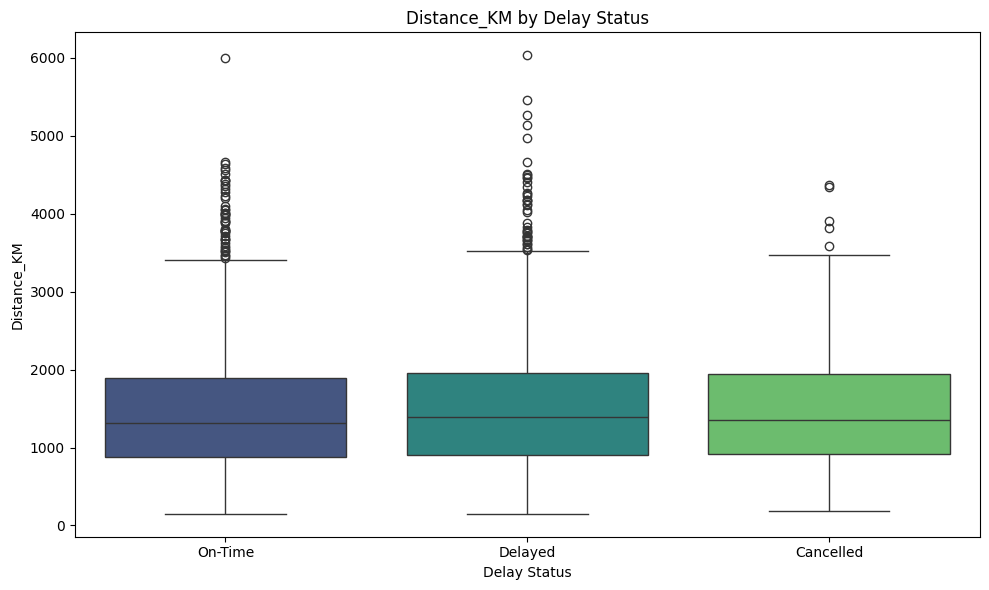


--- Lead_Time_Days statistics by Delay Status ---


,mean,median
Delay_Status,,
Cancelled,27.515748,17.0
Delayed,27.702762,20.0
On-Time,28.047753,19.0


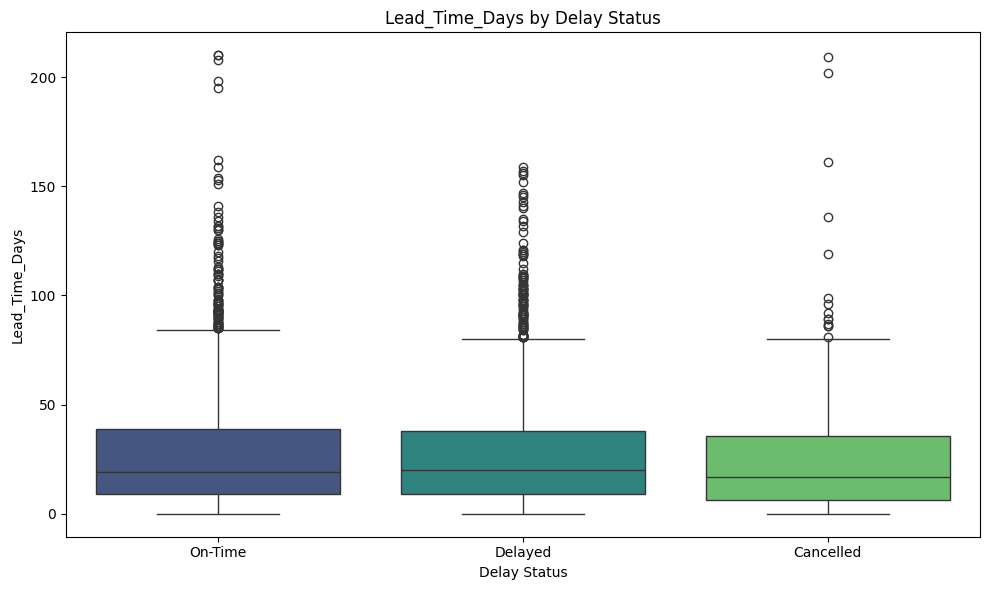

In [58]:
numerical_delay_analysis = [
    "Load_Factor_Flight",
    "Flight_Duration_Hours",
    "Service_Rating",
    "Distance_KM",
    "Lead_Time_Days"
]

for col in numerical_delay_analysis:
    print(f"\n--- {col} statistics by Delay Status ---")

    # Display mean and median of the numerical variable for each delay status
    delay_stats = df.groupby('Delay_Status')[col].agg(['mean', 'median'])
    display(delay_stats)

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df,
        x="Delay_Status",
        y=col,
        palette="viridis",
        hue="Delay_Status",  # Explicitly assign hue to match x for palette
        legend=False         # Hide legend if hue is directly from x
    )
    plt.title(f'{col} by Delay Status')
    plt.xlabel('Delay Status')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

Flight Duration Hours

Flight duration exhibits the clearest relationship with flight delay status. Cancelled flights have the longest average duration (4.67 hours) followed by delayed flights (4.35 hours), while on-time flights have the shortest average duration (3.58 hours). The median values show the same pattern (4.25, 3.92, and 3.28 hours, respectively). This suggests that longer flights are more likely to experience operational disruptions than shorter flights.

Distance (Distance_KM)

Flight distance shows a slight association with delay status. Delayed flights have the highest average travel distance (1,505.48 km), followed closely by cancelled flights (1,498.74 km), whereas on-time flights have the shortest average distance (1,453.04 km). However, the differences are relatively small, indicating that distance alone is unlikely to be a strong determinant of delays.

Among the numerical variables analysed, Flight_Duration_Hours demonstrates the strongest association with flight delay status, with cancelled and delayed flights generally having longer durations than on-time flights. Distance_KM shows a weaker positive relationship, as delayed flights tend to travel slightly longer distances on average. In contrast, Load_Factor_Flight, Service_Rating, and Lead_Time_Days exhibit only negligible differences across delay categories, suggesting that these variables individually contribute limited discriminatory information for predicting flight delay status.

## Correlation Analysis

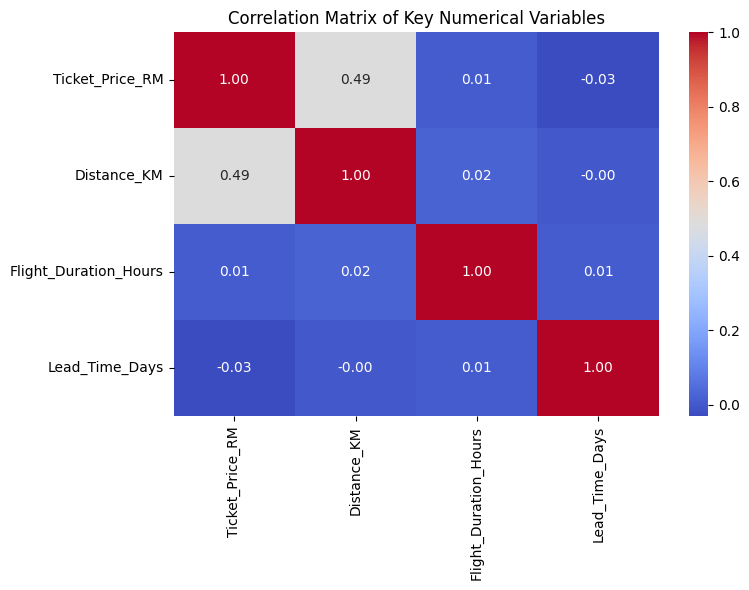

In [59]:
# Correlation matrix heatmap for selected numerical columns
correlation_matrix = df[['Ticket_Price_RM', 'Distance_KM', 'Flight_Duration_Hours', 'Lead_Time_Days']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Numerical Variables')
plt.tight_layout()
plt.show()

The correlation analysis indicates that Distance_KM has the strongest linear relationship with ticket price (r = 0.49), suggesting that longer flights generally have higher fares. In contrast, Flight_Duration_Hours (r = 0.01) and Lead_Time_Days (r = −0.03) exhibit negligible linear correlations with ticket price. Although lead time showed slight differences in the boxplot analysis, the weak correlation suggests that its relationship with ticket price is likely non-linear rather than linear.

## Summary of Key Findings

Overall, the exploratory analysis suggests that different groups of variables contribute differently to the two prediction tasks. Variables related to flight characteristics and customer booking behaviour, such as Cabin_Class, Distance_KM, Booking_Urgency, and Competitor_Avg_Fare_RM, appear more informative for predicting ticket prices. In contrast, operational factors, including Peak_Travel, Airline_Tier, Day_of_Week, and Flight_Duration_Hours, demonstrate stronger associations with flight delay status. These findings provide an initial understanding of the dataset and guide the selection of relevant features for the subsequent machine learning modelling stage.

### Ticket Price (Regression)

- Ticket prices are highly right-skewed, with most tickets priced below RM1,000 and a small number of premium-priced outliers. These outliers were inspected and retained, as no evidence of data entry errors was identified.
- Cabin Class exhibits the strongest relationship with ticket price. Average fares increase consistently from Economy to First Class, indicating that higher service levels command higher prices.
- Booking Urgency also shows a meaningful relationship with ticket price. Passengers who book closer to the departure date generally pay higher fares than those who book well in advance.
- Among the numerical variables, Distance_KM demonstrates a moderate positive relationship with ticket price, suggesting that longer flights tend to cost more. Competitor_Avg_Fare_RM also shows a clear positive relationship with ticket prices, reflecting market-based pricing behaviour.
- In contrast, variables such as Seat_Type, Booking_Channel, Airline_Tier, and Peak_Travel show relatively small differences in ticket prices, suggesting weaker individual relationships with the regression target.

### Flight Delay (Classification)

- The target variable (Delay_Status) is reasonably balanced, with approximately 50.9% On-Time, 43.1% Delayed, and 6.0% Cancelled flights, making it suitable for multi-class classification.
- Peak_Travel demonstrates the strongest association with flight delays. Flights occurring during weekends and public holidays experience substantially higher delay and cancellation rates than those on regular days.
- Airline_Tier also shows a clear relationship with flight punctuality. Budget airlines exhibit the highest proportion of delayed flights, whereas Premium and Full-Service airlines achieve better on-time performance.
- Day_of_Week and Cabin_Class display moderate associations with flight delay, while variables such as Seat_Type, Payment_Type, Meals_Included, and Lead_Time_Days show minimal differences across delay categories.
- Among the numerical variables, Flight_Duration_Hours exhibits the strongest relationship with delay status, with delayed and cancelled flights generally having longer flight durations than on-time flights. Distance_KM shows only a slight association, while Load_Factor_Flight, Service_Rating, and Lead_Time_Days contribute little separation between delay classes.

# Data Preparation for Machine Learning

## Feature Selection

### Regression Feature

In [60]:
# Target variable
y_reg = df["Ticket_Price_RM"]

# Features
X_reg = df.drop(columns=[
   "Booking_ID",
   "Airline_ID",
    "Ticket_Price_RM",
    "Price_per_KM",
    "Fare_Difference",
    "Delay_Status",
    "Satisfaction_Rating",
    "Review_Score",
    "Total_Spend_RM",
   "Extra_Spend_Unscaled",
    "Load_Service",
   "Extra_Spend_Unscaled",
   "Departure_Date",
   "Departure_Month",
   "Service_Rating",
   "Day_of_Month",
   "Is_Weekend",
  "Is_Public_Holiday"
])

print("Regression Features Shape:", X_reg.shape)
print("Regression Target Shape:", y_reg.shape)

X_reg.head()

Regression Features Shape: (4200, 20)
Regression Target Shape: (4200,)


,Country,Airline_Tier,Cabin_Class,Seat_Type,Flight_Duration_Hours,Booking_Channel,Meals_Included,Payment_Type,Passenger_Age,Lead_Time_Days,Load_Factor_Flight,Competitor_Avg_Fare_RM,Distance_KM,Promo_Applied,Events_Index_Destination,Day_of_Week,Quarter,Booking_Urgency,LeadTime_Promo,Peak_Travel
0,Malaysia,Premium,Economy,Window,3.13,Website,True,Card,51.0,5,0.836,363.74,1106.6,False,47.7,Thursday,4,Last Minute,0,Regular Day
1,Malaysia,Budget,Premium Economy,Window,0.75,Walk-In,True,Online,34.0,47,0.806,612.09,1962.9,True,46.1,Saturday,1,Advance,47,Weekend
2,Indonesia,Full-Service,Economy,Window,4.00,Mobile App,False,Online,37.0,87,0.368,971.42,3013.9,False,47.1,Sunday,1,Advance,0,Weekend
3,Thailand,Budget,Economy,Aisle,2.80,Mobile App,False,Cash,28.0,19,0.920,439.45,1234.8,True,66.4,Friday,4,Short Notice,19,Regular Day
4,Indonesia,Full-Service,Economy,Middle,6.99,Walk-In,False,Card,45.0,14,0.648,721.79,2034.7,False,73.9,Tuesday,4,Short Notice,0,Regular Day


In [61]:
#feature check
print(X_reg.columns.tolist())

['Country', 'Airline_Tier', 'Cabin_Class', 'Seat_Type', 'Flight_Duration_Hours', 'Booking_Channel', 'Meals_Included', 'Payment_Type', 'Passenger_Age', 'Lead_Time_Days', 'Load_Factor_Flight', 'Competitor_Avg_Fare_RM', 'Distance_KM', 'Promo_Applied', 'Events_Index_Destination', 'Day_of_Week', 'Quarter', 'Booking_Urgency', 'LeadTime_Promo', 'Peak_Travel']


### Classification Feature

In [94]:
# Target variable
y_clf = df["Delay_Status"]

# Features
X_clf = df.drop(columns=[
    "Booking_ID",
    "Ticket_Price_RM",
    "Delay_Status",
    "Airline_ID",
    "Service_Rating",
    "Departure_Date",
    "Departure_Month",
    "Is_Weekend",
    "Is_Public_Holiday",
    "Review_Score",
    "Satisfaction_Rating",
    "Total_Spend_RM",
    "Extra_Spend_Unscaled",
    "Price_per_KM",
    "Fare_Difference",
    "Load_Service",
    "Passenger_Age",
    "Booking_Channel",
    "Payment_Type",
    "Meals_Included"
])

print("Classification Features Shape:", X_clf.shape)
print("Classification Target Shape:", y_clf.shape)

X_clf.head()

Classification Features Shape: (4200, 17)
Classification Target Shape: (4200,)


,Country,Airline_Tier,Cabin_Class,Seat_Type,Flight_Duration_Hours,Lead_Time_Days,Load_Factor_Flight,Competitor_Avg_Fare_RM,Distance_KM,Promo_Applied,Events_Index_Destination,Day_of_Week,Day_of_Month,Quarter,Booking_Urgency,LeadTime_Promo,Peak_Travel
0,Malaysia,Premium,Economy,Window,3.13,5,0.836,363.74,1106.6,False,47.7,Thursday,10,4,Last Minute,0,Regular Day
1,Malaysia,Budget,Premium Economy,Window,0.75,47,0.806,612.09,1962.9,True,46.1,Saturday,15,1,Advance,47,Weekend
2,Indonesia,Full-Service,Economy,Window,4.00,87,0.368,971.42,3013.9,False,47.1,Sunday,2,1,Advance,0,Weekend
3,Thailand,Budget,Economy,Aisle,2.80,19,0.920,439.45,1234.8,True,66.4,Friday,4,4,Short Notice,19,Regular Day
4,Indonesia,Full-Service,Economy,Middle,6.99,14,0.648,721.79,2034.7,False,73.9,Tuesday,1,4,Short Notice,0,Regular Day


In [95]:
#feature check
print(X_clf.columns.tolist())

['Country', 'Airline_Tier', 'Cabin_Class', 'Seat_Type', 'Flight_Duration_Hours', 'Lead_Time_Days', 'Load_Factor_Flight', 'Competitor_Avg_Fare_RM', 'Distance_KM', 'Promo_Applied', 'Events_Index_Destination', 'Day_of_Week', 'Day_of_Month', 'Quarter', 'Booking_Urgency', 'LeadTime_Promo', 'Peak_Travel']


## Train-Test Split

In [96]:
label_encoder = LabelEncoder()
y_clf_encoded = label_encoder.fit_transform(y_clf)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X_clf, y_clf_encoded, test_size=0.2, random_state=42, stratify=y_clf_encoded)

print("Regression Train Features Shape:", X_train_reg.shape)
print("Regression Test Features Shape:", X_test_reg.shape)
print("Classification Train Features Shape:", X_train_clf.shape)
print("Classification Test Features Shape:", X_test_clf.shape)

Regression Train Features Shape: (3360, 20)
Regression Test Features Shape: (840, 20)
Classification Train Features Shape: (3360, 17)
Classification Test Features Shape: (840, 17)


## Feature Encoding & Scaling

In [97]:
#regression variable
categorical_reg = [
    "Country",
    "Airline_Tier",
    "Cabin_Class",
    "Seat_Type",
    "Booking_Channel",
    "Meals_Included",
    "Payment_Type",
    "Promo_Applied",
    "Day_of_Week",
    "Quarter",
    "Booking_Urgency",
    "Peak_Travel"
]

numerical_reg = [
    "Flight_Duration_Hours",
    "Passenger_Age",
    "Lead_Time_Days",
    "Load_Factor_Flight",
    "Competitor_Avg_Fare_RM",
    "Distance_KM",
    "Events_Index_Destination",
    "LeadTime_Promo"
]

In [100]:
#classification variable
categorical_clf = [
    "Country",
    "Airline_Tier",
    "Cabin_Class",
    "Seat_Type",
    "Promo_Applied",
    "Day_of_Week",
    "Quarter",
    "Booking_Urgency",
    "Peak_Travel"
]

numerical_clf = [
    "Flight_Duration_Hours",
    "Lead_Time_Days",
    "Load_Factor_Flight",
    "Competitor_Avg_Fare_RM",
    "Distance_KM",
    "Events_Index_Destination",
    "LeadTime_Promo",
    "Day_of_Month"
]

## Feature Scaling

In [101]:
# Re-define preprocessor_reg to include StandardScaler for numerical features
preprocessor_reg = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_reg),
        ("num", StandardScaler(), numerical_reg) # Apply StandardScaler here
    ]
)

# Re-define preprocessor_clf to include StandardScaler for numerical features
preprocessor_clf = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_clf),
        ("num", StandardScaler(), numerical_clf) # Apply StandardScaler here
    ]
)

# Apply the updated preprocessing for regression features
X_train_reg_scaled = preprocessor_reg.fit_transform(X_train_reg)
X_test_reg_scaled = preprocessor_reg.transform(X_test_reg)

# Apply the updated preprocessing for classification features
X_train_clf_scaled = preprocessor_clf.fit_transform(X_train_clf)
X_test_clf_scaled = preprocessor_clf.transform(X_test_clf)

print("Regression Train Features Scaled Shape:", X_train_reg_scaled.shape)
print("Regression Test Features Scaled Shape:", X_test_reg_scaled.shape)
print("Classification Train Features Scaled Shape:", X_train_clf_scaled.shape)
print("Classification Test Features Scaled Shape:", X_test_clf_scaled.shape)

Regression Train Features Scaled Shape: (3360, 45)
Regression Test Features Scaled Shape: (840, 45)
Classification Train Features Scaled Shape: (3360, 38)
Classification Test Features Scaled Shape: (840, 38)


## Handling Class Imbalance

For the classification task, we have an imbalanced target variable (`Delay_Status`). To prevent the model from being biased towards the majority class ('On-Time' or 'Delayed'), we will use SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic samples for the minority classes ('Cancelled'). This will help create a more balanced training set for the classification model.

In [102]:
# Check the class distribution before SMOTE
print("Class distribution before SMOTE:")
print(pd.Series(y_train_clf).value_counts())

smote = SMOTE(random_state=42)
X_train_clf_res, y_train_clf_res = smote.fit_resample(X_train_clf_scaled, y_train_clf)

# Check the class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_clf_res).value_counts())

print("\nShape of X_train_clf_res:", X_train_clf_res.shape)
print("Shape of y_train_clf_res:", y_train_clf_res.shape)

Class distribution before SMOTE:
2    1709
1    1448
0     203
Name: count, dtype: int64

Class distribution after SMOTE:
2    1709
1    1709
0    1709
Name: count, dtype: int64

Shape of X_train_clf_res: (5127, 38)
Shape of y_train_clf_res: (5127,)


# Regression Modelling

## Linear Regression

In [80]:
# Initialize and train the Linear Regression model
lin_reg_model = LinearRegression()
lin_reg_model.fit(X_train_reg_scaled, y_train_reg)

# Make predictions on the test set
y_pred_lin_reg = lin_reg_model.predict(X_test_reg_scaled)

# Evaluate the model
mae_lin_reg = mean_absolute_error(y_test_reg, y_pred_lin_reg)
mse_lin_reg = mean_squared_error(y_test_reg, y_pred_lin_reg)
rmse_lin_reg = np.sqrt(mse_lin_reg)
r2_lin_reg = r2_score(y_test_reg, y_pred_lin_reg)

print("Linear Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_lin_reg:.2f}")
print(f"Mean Squared Error (MSE): {mse_lin_reg:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_lin_reg:.2f}")
print(f"R-squared (R2): {r2_lin_reg:.2f}")

Linear Regression Model Performance:
Mean Absolute Error (MAE): 86.36
Mean Squared Error (MSE): 256544.17
Root Mean Squared Error (RMSE): 506.50
R-squared (R2): 0.21


The Linear Regression model achieved the best overall performance among all regression models. It recorded the lowest prediction errors and the highest R-squared value, indicating that it was the most effective model for predicting airline ticket prices in this dataset.


## Initial Model (RandomForestRegressor)

In [69]:
# Initialize and train the RandomForestRegressor
reg_model = RandomForestRegressor(random_state=42)
reg_model.fit(X_train_reg_scaled, y_train_reg)

# Make predictions on the test set
y_pred_reg = reg_model.predict(X_test_reg_scaled)

# Evaluate the model
mae_reg = mean_absolute_error(y_test_reg, y_pred_reg)
mse_reg = mean_squared_error(y_test_reg, y_pred_reg)
rmse_reg = np.sqrt(mse_reg)
r2_reg = r2_score(y_test_reg, y_pred_reg)

print("Regression Model Performance:")
print(f"Mean Absolute Error (MAE): {mae_reg:.2f}")
print(f"Mean Squared Error (MSE): {mse_reg:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_reg:.2f}")
print(f"R-squared (R2): {r2_reg:.2f}")

Regression Model Performance:
Mean Absolute Error (MAE): 97.62
Mean Squared Error (MSE): 273794.78
Root Mean Squared Error (RMSE): 523.25
R-squared (R2): 0.15


The initial Random Forest Regressor produced moderate predictive performance. While it was able to capture some relationships within the data, its prediction errors were higher and explanatory power was lower than the Linear Regression model.


## Tuned Regression

In [70]:
param_grid_reg = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Initialize RandomizedSearchCV for RandomForestRegressor
# Using 'neg_mean_absolute_error' for scoring (higher is better for negative scores)
random_search_reg = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid_reg,
    n_iter=20,          # Try 20 combinations for efficiency
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit RandomizedSearchCV on the scaled training data
random_search_reg.fit(X_train_reg_scaled, y_train_reg)

# Get the best parameters and best score
best_params_reg = random_search_reg.best_params_
best_score_reg = -random_search_reg.best_score_ # Convert back to positive MAE

print(f"Best Parameters (Tuned Random Forest Regressor): {best_params_reg}")
print(f"Best Mean Absolute Error (MAE) on CV: {best_score_reg:.2f}")

# Get the best regression model
best_reg_model = random_search_reg.best_estimator_

# Make predictions on the test set with the best model
y_pred_reg_tuned = best_reg_model.predict(X_test_reg_scaled)

# Evaluate the tuned model
mae_reg_tuned = mean_absolute_error(y_test_reg, y_pred_reg_tuned)
mse_reg_tuned = mean_squared_error(y_test_reg, y_pred_reg_tuned)
rmse_reg_tuned = np.sqrt(mse_reg_tuned)
r2_reg_tuned = r2_score(y_test_reg, y_pred_reg_tuned)

print("\nRegression Model Performance (Tuned Random Forest):")
print(f"Mean Absolute Error (MAE): {mae_reg_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_reg_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_reg_tuned:.2f}")
print(f"R-squared (R2): {r2_reg_tuned:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters (Tuned Random Forest Regressor): {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
Best Mean Absolute Error (MAE) on CV: 86.70

Regression Model Performance (Tuned Random Forest):
Mean Absolute Error (MAE): 92.30
Mean Squared Error (MSE): 262120.55
Root Mean Squared Error (RMSE): 511.98
R-squared (R2): 0.19


Hyperparameter tuning improved the Random Forest Regressor by reducing prediction errors and increasing the R-squared value. Although the tuned model performed better than the initial model, it still did not outperform the Linear Regression model.



## XGBoost Regressor

In [85]:
# Initialize and train the XGBoost Regressor
xgb_reg_model = XGBRegressor(random_state=42, n_jobs=-1)
xgb_reg_model.fit(X_train_reg_scaled, y_train_reg)

# Make predictions on the test set
y_pred_xgb_reg = xgb_reg_model.predict(X_test_reg_scaled)

# Evaluate the model
mae_xgb_reg = mean_absolute_error(y_test_reg, y_pred_xgb_reg)
mse_xgb_reg = mean_squared_error(y_test_reg, y_pred_xgb_reg)
rmse_xgb_reg = np.sqrt(mse_xgb_reg)
r2_xgb_reg = r2_score(y_test_reg, y_pred_xgb_reg)

print("XGBoost Regressor Performance:")
print(f"Mean Absolute Error (MAE): {mae_xgb_reg:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb_reg:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_reg:.2f}")
print(f"R-squared (R2): {r2_xgb_reg:.2f}")

XGBoost Regressor Performance:
Mean Absolute Error (MAE): 100.72
Mean Squared Error (MSE): 268632.57
Root Mean Squared Error (RMSE): 518.30
R-squared (R2): 0.17


The initial XGBoost Regressor showed reasonable predictive performance but produced higher prediction errors than both the Linear Regression and tuned Random Forest models.


## Tuned XGBoost Regressor

In [86]:
# Define the parameter grid for XGBoost Regressor
param_grid_xgb_reg = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1]
}

# Initialize RandomizedSearchCV for XGBoostRegressor
# Using 'neg_mean_absolute_error' for scoring (higher is better for negative scores)
random_search_xgb_reg = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1),
    param_distributions=param_grid_xgb_reg,
    n_iter=20,          # Try 20 combinations for efficiency
    cv=5,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# Fit RandomizedSearchCV on the scaled training data
random_search_xgb_reg.fit(X_train_reg_scaled, y_train_reg)

# Get the best parameters and best score
best_params_xgb_reg = random_search_xgb_reg.best_params_
best_score_xgb_reg = -random_search_xgb_reg.best_score_ # Convert back to positive MAE

print(f"Best Parameters (Tuned XGBoost Regressor): {best_params_xgb_reg}")
print(f"Best Mean Absolute Error (MAE) on CV: {best_score_xgb_reg:.2f}")

# Get the best XGBoost model
best_xgb_reg_model = random_search_xgb_reg.best_estimator_

# Make predictions on the test set with the best model
y_pred_xgb_reg_tuned = best_xgb_reg_model.predict(X_test_reg_scaled)

# Evaluate the tuned model
mae_xgb_reg_tuned = mean_absolute_error(y_test_reg, y_pred_xgb_reg_tuned)
mse_xgb_reg_tuned = mean_squared_error(y_test_reg, y_pred_xgb_reg_tuned)
rmse_xgb_reg_tuned = np.sqrt(mse_xgb_reg_tuned)
r2_xgb_reg_tuned = r2_score(y_test_reg, y_pred_xgb_reg_tuned)

print("\nRegression Model Performance (Tuned XGBoost):")
print(f"Mean Absolute Error (MAE): {mae_xgb_reg_tuned:.2f}")
print(f"Mean Squared Error (MSE): {mse_xgb_reg_tuned:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb_reg_tuned:.2f}")
print(f"R-squared (R2): {r2_xgb_reg_tuned:.2f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters (Tuned XGBoost Regressor): {'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best Mean Absolute Error (MAE) on CV: 91.93

Regression Model Performance (Tuned XGBoost):
Mean Absolute Error (MAE): 92.61
Mean Squared Error (MSE): 259775.67
Root Mean Squared Error (RMSE): 509.68
R-squared (R2): 0.20


Hyperparameter tuning improved the XGBoost Regressor by reducing prediction errors and increasing the R-squared value. The tuned model outperformed the initial XGBoost model and achieved competitive performance, although Linear Regression remained the best-performing model overall.


## Performance Comparison

In [87]:
# Prepare data for comparison
model_names = [
    "Linear Regression",
    "Random Forest Regressor (Initial)",
    "Random Forest Regressor (Tuned)",
    "XGBoost Regressor (Initial)",
    "XGBoost Regressor (Tuned)"
]

mae_scores = [
    mae_lin_reg,
    mae_reg,
    mae_reg_tuned,
    mae_xgb_reg,
    mae_xgb_reg_tuned
]

mse_scores = [
    mse_lin_reg,
    mse_reg,
    mse_reg_tuned,
    mse_xgb_reg,
    mse_xgb_reg_tuned
]

rmse_scores = [
    rmse_lin_reg,
    rmse_reg,
    rmse_reg_tuned,
    rmse_xgb_reg,
    rmse_xgb_reg_tuned
]

r2_scores = [
    r2_lin_reg,
    r2_reg,
    r2_reg_tuned,
    r2_xgb_reg,
    r2_xgb_reg_tuned
]

# Create a summary table
summary_data_reg = []
for i, name in enumerate(model_names):
    summary_data_reg.append([
        name,
        f'{mae_scores[i]:.2f}',
        f'{mse_scores[i]:.2f}',
        f'{rmse_scores[i]:.2f}',
        f'{r2_scores[i]:.2f}'
    ])

headers_reg = ["Model", "MAE", "MSE", "RMSE", "R-squared"]
print("## Regression Model Performance Comparison")
print(tabulate(summary_data_reg, headers=headers_reg, tablefmt="grid"))

## Regression Model Performance Comparison
+-----------------------------------+--------+--------+--------+-------------+
| Model                             |    MAE |    MSE |   RMSE |   R-squared |
+===================================+========+========+========+=============+
| Linear Regression                 |  86.36 | 256544 | 506.5  |        0.21 |
+-----------------------------------+--------+--------+--------+-------------+
| Random Forest Regressor (Initial) |  97.62 | 273795 | 523.25 |        0.15 |
+-----------------------------------+--------+--------+--------+-------------+
| Random Forest Regressor (Tuned)   |  92.3  | 262121 | 511.98 |        0.19 |
+-----------------------------------+--------+--------+--------+-------------+
| XGBoost Regressor (Initial)       | 100.72 | 268633 | 518.3  |        0.17 |
+-----------------------------------+--------+--------+--------+-------------+
| XGBoost Regressor (Tuned)         |  92.61 | 259776 | 509.68 |        0.2  |
+--------

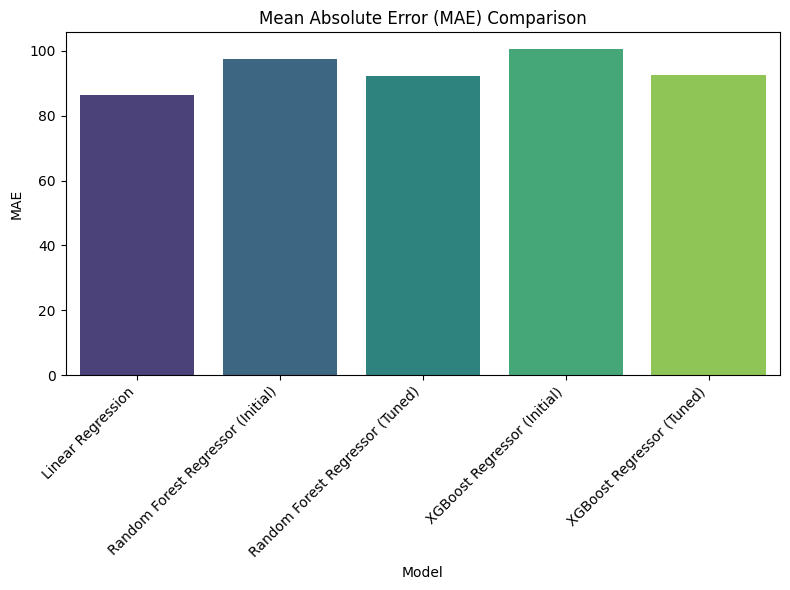

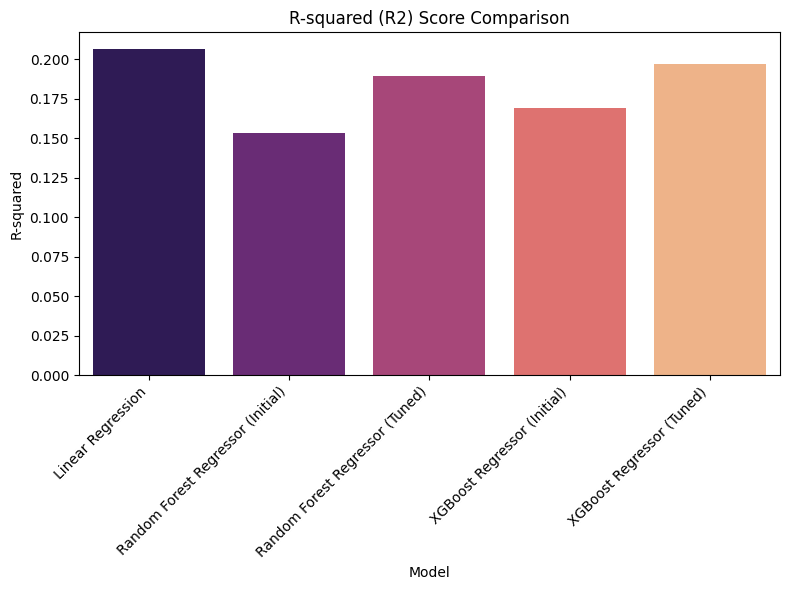

In [91]:
plt.figure(figsize=(8, 6))

# Plot MAE scores
sns.barplot(x=model_names, y=mae_scores, palette='viridis', hue=model_names, legend=False)
plt.title('Mean Absolute Error (MAE) Comparison')
plt.xlabel('Model')
plt.ylabel('MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))

# Plot R-squared scores
sns.barplot(x=model_names, y=r2_scores, palette='magma', hue=model_names, legend=False)
plt.title('R-squared (R2) Score Comparison')
plt.xlabel('Model')
plt.ylabel('R-squared')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The performance of all regression models was compared using MAE, MSE, RMSE, and R². Among the evaluated models, **Linear Regression** achieved the lowest prediction errors and the highest R² score, making it the best-performing model for predicting airline ticket prices. Although hyperparameter tuning improved the Random Forest and XGBoost models, neither surpassed the performance of Linear Regression.

## Feature Importance

Top 20 Feature Importances (Linear Regression):
                             Feature  Importance
42                  num__Distance_KM  189.509645
9           cat__Cabin_Class_Economy  184.607678
21           cat__Promo_Applied_True  124.539090
10            cat__Cabin_Class_First   73.306577
41       num__Competitor_Avg_Fare_RM   60.910440
11  cat__Cabin_Class_Premium Economy   59.355397
13             cat__Seat_Type_Window   48.084929
27        cat__Day_of_Week_Wednesday   45.211264
26          cat__Day_of_Week_Tuesday   40.881868
31   cat__Booking_Urgency_Early Bird   39.642369
8          cat__Airline_Tier_Premium   36.645583
22           cat__Day_of_Week_Monday   33.476319
39               num__Lead_Time_Days   32.439990
14   cat__Booking_Channel_Mobile App   26.771883
5              cat__Country_Thailand   24.150858
16      cat__Booking_Channel_Walk-In   22.207539
6               cat__Country_Vietnam   19.627468
0             cat__Country_Indonesia   15.650813
12             cat__S

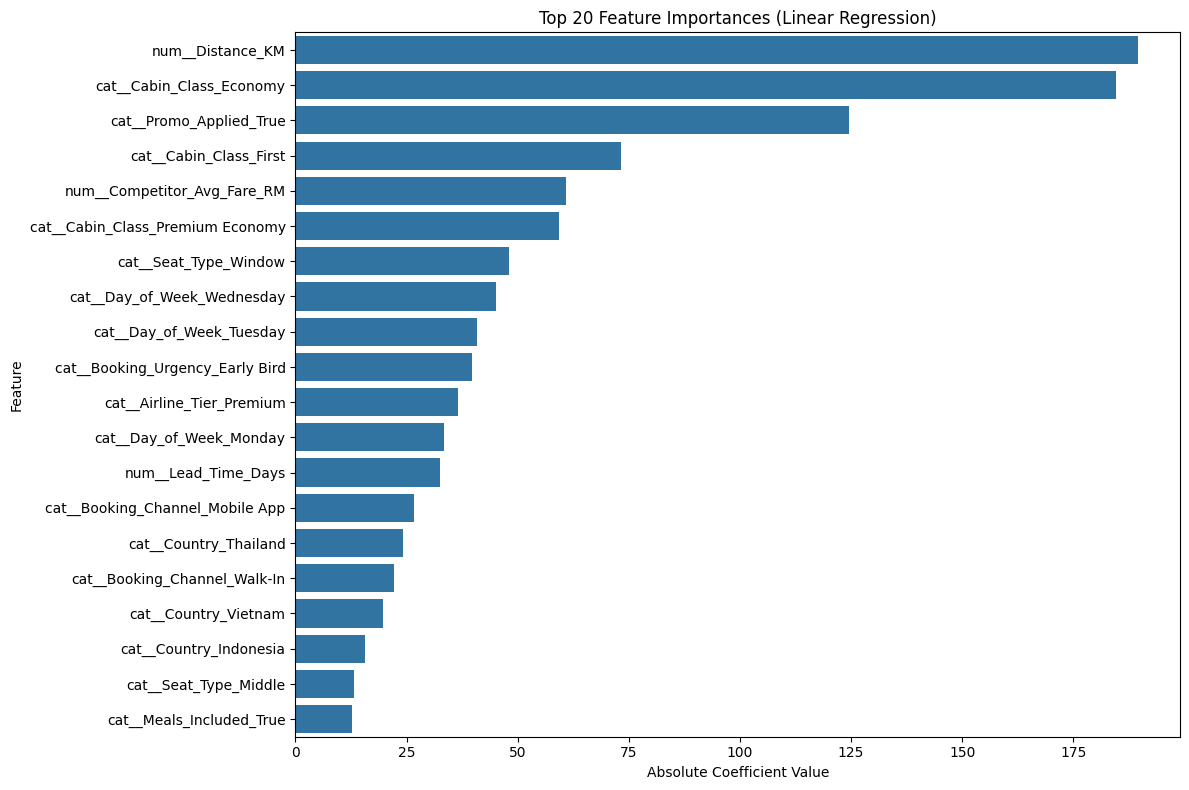

In [88]:
importances_reg = np.abs(lin_reg_model.coef_)

feature_names_reg = preprocessor_reg.get_feature_names_out()

feature_importance_df_reg = pd.DataFrame({
    'Feature': feature_names_reg,
    'Importance': importances_reg
})

feature_importance_df_reg = feature_importance_df_reg.sort_values(by='Importance', ascending=False)

print("Top 20 Feature Importances (Linear Regression):")
print(feature_importance_df_reg.head(20))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_reg.head(20))
plt.title('Top 20 Feature Importances (Linear Regression)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The coefficient analysis shows that **Distance_KM**, **Cabin_Class**, **Promo_Applied**, **Competitor_Avg_Fare_RM**, and **Lead_Time_Days** were among the most influential factors affecting airline ticket prices. These findings suggest that ticket pricing is primarily driven by travel distance, service level, promotional strategies, market competition, and booking behaviour. From a business perspective, airlines can leverage these insights to optimise dynamic pricing strategies, design targeted promotional campaigns, and adjust fares based on competitor pricing and customer booking patterns to maximise revenue while remaining competitive.


# Classification Modelling

## Logistic Regression

In [103]:
# Initialize and train the Logistic Regression Classifier with resampled data
log_reg_model = LogisticRegression(random_state=42, solver='liblinear', multi_class='ovr', n_jobs=-1)
log_reg_model.fit(X_train_clf_res, y_train_clf_res)

# Make predictions on the test set (using scaled but not resampled test data)
y_pred_log_reg = log_reg_model.predict(X_test_clf_scaled)

# Evaluate the model
accuracy_log_reg = accuracy_score(y_test_clf, y_pred_log_reg)
report_log_reg = classification_report(y_test_clf, y_pred_log_reg)
conf_matrix_log_reg = confusion_matrix(y_test_clf, y_pred_log_reg)

print("Classification Model Performance (Logistic Regression):")
print(f"Accuracy: {accuracy_log_reg:.2f}")
print("\nClassification Report:\n", report_log_reg)
print("\nConfusion Matrix:\n", conf_matrix_log_reg)

Classification Model Performance (Logistic Regression):
Accuracy: 0.45

Classification Report:
               precision    recall  f1-score   support

           0       0.10      0.45      0.16        51
           1       0.50      0.25      0.33       362
           2       0.62      0.62      0.62       427

    accuracy                           0.45       840
   macro avg       0.41      0.44      0.37       840
weighted avg       0.54      0.45      0.47       840


Confusion Matrix:
 [[ 23  12  16]
 [127  89 146]
 [ 84  78 265]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


The Logistic Regression model served as the baseline classifier for predicting flight delay status. Although it achieved the lowest overall accuracy and weighted F1-score, it demonstrated the highest recall for the **Cancelled** class, indicating a greater ability to identify minority-class flights. From a business perspective, this may help airlines detect potential cancellations earlier; however, the model's lower overall predictive performance limits its effectiveness for operational deployment.


## Initial Model (Random Forest)

In [104]:
# Initialize and train the RandomForestClassifier with resampled data
clf_model = RandomForestClassifier(random_state=42)
clf_model.fit(X_train_clf_res, y_train_clf_res)

# Make predictions on the test set (using scaled but not resampled test data)
y_pred_clf = clf_model.predict(X_test_clf_scaled)

# Evaluate the model
accuracy_clf = accuracy_score(y_test_clf, y_pred_clf)
report_clf = classification_report(y_test_clf, y_pred_clf)
conf_matrix_clf = confusion_matrix(y_test_clf, y_pred_clf)

print("Classification Model Performance (Random Forest):")
print(f"Accuracy: {accuracy_clf:.2f}")
print("\nClassification Report:\n", report_clf)
print("\nConfusion Matrix:\n", conf_matrix_clf)

Classification Model Performance (Random Forest):
Accuracy: 0.60

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.58      0.53      0.55       362
           2       0.63      0.73      0.68       427

    accuracy                           0.60       840
   macro avg       0.40      0.42      0.41       840
weighted avg       0.57      0.60      0.58       840


Confusion Matrix:
 [[  0  30  21]
 [  4 193 165]
 [  2 112 313]]


The initial Random Forest Classifier achieved the best overall classification performance, recording the highest Accuracy and Weighted F1-score among all evaluated models. The model classified **Delayed** and **On-Time** flights effectively, although it was unable to correctly identify **Cancelled** flights due to the highly imbalanced class distribution. From a business perspective, the model can support airlines in anticipating delays and improving operational planning for the majority of flights.


## Fine-Tuning Random Forest

In [105]:
# Define the parameter grid for Random Forest Classifier
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Initialize RandomizedSearchCV
# Using 'f1_weighted' as scoring to account for class imbalance
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=20,          # Try only 20 combinations
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Fit RandomizedSearchCV on the resampled training data
random_search.fit(X_train_clf_res, y_train_clf_res)

# Get the best parameters and best score
best_params = random_search.best_params_
best_score = random_search.best_score_

print(f"Best Parameters: {best_params}")
print(f"Best F1-weighted Score: {best_score:.4f}")

# Get the best model
best_clf_model = random_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_clf_tuned = best_clf_model.predict(X_test_clf_scaled)

# Evaluate the tuned model
accuracy_clf_tuned = accuracy_score(y_test_clf, y_pred_clf_tuned)
report_clf_tuned = classification_report(y_test_clf, y_pred_clf_tuned)
conf_matrix_clf_tuned = confusion_matrix(y_test_clf, y_pred_clf_tuned)

print("\nClassification Model Performance (Tuned Random Forest):")
print(f"Accuracy: {accuracy_clf_tuned:.2f}")
print("\nClassification Report:\n", report_clf_tuned)
print("\nConfusion Matrix:\n", conf_matrix_clf_tuned)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}
Best F1-weighted Score: 0.7151

Classification Model Performance (Tuned Random Forest):
Accuracy: 0.59

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.56      0.52      0.54       362
           2       0.62      0.73      0.67       427

    accuracy                           0.59       840
   macro avg       0.39      0.42      0.40       840
weighted avg       0.56      0.59      0.57       840


Confusion Matrix:
 [[  0  31  20]
 [  3 188 171]
 [  3 114 310]]


Hyperparameter tuning produced performance comparable to the initial Random Forest model but did not improve its overall predictive performance. Although the tuned model remained competitive, the initial Random Forest Classifier achieved slightly higher Accuracy and Weighted F1-score and was therefore selected as the final classification model.


## XGBoost

In [106]:
# Initialize and train the XGBoost Classifier with resampled data
xgb_model = XGBClassifier(random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train_clf_res, y_train_clf_res)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test_clf_scaled)

# Evaluate the model
accuracy_xgb = accuracy_score(y_test_clf, y_pred_xgb)
report_xgb = classification_report(y_test_clf, y_pred_xgb)
conf_matrix_xgb = confusion_matrix(y_test_clf, y_pred_xgb)

print("Classification Model Performance (XGBoost Classifier):")
print(f"Accuracy: {accuracy_xgb:.2f}")
print("\nClassification Report:\n", report_xgb)
print("\nConfusion Matrix:\n", conf_matrix_xgb)

Classification Model Performance (XGBoost Classifier):
Accuracy: 0.55

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.51      0.50      0.51       362
           2       0.59      0.65      0.62       427

    accuracy                           0.55       840
   macro avg       0.37      0.39      0.37       840
weighted avg       0.52      0.55      0.53       840


Confusion Matrix:
 [[  0  32  19]
 [  3 182 177]
 [  4 144 279]]


The initial XGBoost Classifier achieved moderate predictive performance but did not outperform the Random Forest models. The model classified **Delayed** and **On-Time** flights reasonably well but was unable to identify **Cancelled** flights. This suggests that while XGBoost captured general delay patterns, its overall performance was less effective for the flight delay prediction task.


## Tuned XGBoost

In [107]:
# Define the parameter grid for XGBoost Classifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1]
}

# Initialize RandomizedSearchCV for XGBoost
# Using 'f1_weighted' as scoring to account for class imbalance
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
    param_distributions=param_grid_xgb,
    n_iter=20,          # Try 20 combinations for efficiency
    cv=5,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1, # Use all available cores
    verbose=2
)

# Fit RandomizedSearchCV on the resampled training data
random_search_xgb.fit(X_train_clf_res, y_train_clf_res)

# Get the best parameters and best score
best_params_xgb = random_search_xgb.best_params_
best_score_xgb = random_search_xgb.best_score_

print(f"Best Parameters (XGBoost): {best_params_xgb}")
print(f"Best F1-weighted Score (XGBoost): {best_score_xgb:.4f}")

# Get the best XGBoost model
best_xgb_model = random_search_xgb.best_estimator_

# Make predictions on the test set with the best model
y_pred_xgb_tuned = best_xgb_model.predict(X_test_clf_scaled)

# Evaluate the tuned XGBoost model
accuracy_xgb_tuned = accuracy_score(y_test_clf, y_pred_xgb_tuned)
report_xgb_tuned = classification_report(y_test_clf, y_pred_xgb_tuned)
conf_matrix_xgb_tuned = confusion_matrix(y_test_clf, y_pred_xgb_tuned)

print("\nClassification Model Performance (Tuned XGBoost Classifier):")
print(f"Accuracy: {accuracy_xgb_tuned:.2f}")
print("\nClassification Report:\n", report_xgb_tuned)
print("\nConfusion Matrix:\n", conf_matrix_xgb_tuned)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:06:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters (XGBoost): {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 10, 'learning_rate': 0.05, 'gamma': 0.5, 'colsample_bytree': 0.8}
Best F1-weighted Score (XGBoost): 0.6866

Classification Model Performance (Tuned XGBoost Classifier):
Accuracy: 0.59

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        51
           1       0.56      0.54      0.55       362
           2       0.62      0.70      0.65       427

    accuracy                           0.59       840
   macro avg       0.39      0.41      0.40       840
weighted avg       0.56      0.59      0.57       840


Confusion Matrix:
 [[  0  27  24]
 [  4 196 162]
 [  3 126 298]]


Hyperparameter tuning improved the XGBoost Classifier, increasing both Accuracy and the Weighted F1-score. However, its overall performance remained slightly below that of the Initial Random Forest Classifier, which achieved the best classification results.


## Performance Comparison

In [108]:
# Prepare data for comparison
model_names = [
    "Logistic Regression",
    "Random Forest (Initial)",
    "Random Forest (Tuned)",
    "XGBoost (Initial)",
    "XGBoost (Tuned)"
]

accuracies = [
    accuracy_log_reg,
    accuracy_clf,
    accuracy_clf_tuned,
    accuracy_xgb,
    accuracy_xgb_tuned
]

reports = [
    report_log_reg,
    report_clf,
    report_clf_tuned,
    report_xgb,
    report_xgb_tuned
]

conf_matrices = [
    conf_matrix_log_reg,
    conf_matrix_clf,
    conf_matrix_clf_tuned,
    conf_matrix_xgb,
    conf_matrix_xgb_tuned
]

# Extract key metrics from classification reports for summary table
def extract_f1_scores(report_str):
    lines = report_str.split('\n')
    metrics = {}
    for line in lines:
        if 'macro avg' in line or 'weighted avg' in line:
            parts = line.split()
            if len(parts) >= 4:
                avg_type = parts[0] + ' ' + parts[1]
                f1 = float(parts[4]) # F1-score is the 5th element
                metrics[avg_type] = f1
        elif '0' in line or '1' in line or '2' in line:
            parts = line.split()
            if len(parts) >= 5:
                class_label = parts[0]
                f1 = float(parts[3])
                metrics[f'f1_class_{class_label}'] = f1
    return metrics

summary_data = []
for i, name in enumerate(model_names):
    f1_scores = extract_f1_scores(reports[i])
    summary_data.append([
        name,
        f'{accuracies[i]:.2f}',
        f'{f1_scores.get("f1_class_0", 0.0):.2f}', # F1 for Cancelled
        f'{f1_scores.get("f1_class_1", 0.0):.2f}', # F1 for Delayed
        f'{f1_scores.get("f1_class_2", 0.0):.2f}',  # F1 for On-Time
        f'{f1_scores.get("weighted avg", 0.0):.2f}'
    ])

headers = ["Model", "Accuracy", "F1 (Cancelled)", "F1 (Delayed)", "F1 (On-Time)", "Weighted F1"]
print("## Model Performance Comparison")
print(tabulate(summary_data, headers=headers, tablefmt="grid"))

print("\n--- Detailed Classification Reports and Confusion Matrices ---\n")

for i, name in enumerate(model_names):
    print(f"### {name}")
    print("\nAccuracy:", f'{accuracies[i]:.2f}')
    print("\nClassification Report:\n", reports[i])
    print("\nConfusion Matrix:\n", conf_matrices[i])
    print("\n" + "="*60 + "\n")

## Model Performance Comparison
+-------------------------+------------+------------------+----------------+----------------+---------------+
| Model                   |   Accuracy |   F1 (Cancelled) |   F1 (Delayed) |   F1 (On-Time) |   Weighted F1 |
+=========================+============+==================+================+================+===============+
| Logistic Regression     |       0.45 |             0.16 |           0.33 |           0.62 |          0.47 |
+-------------------------+------------+------------------+----------------+----------------+---------------+
| Random Forest (Initial) |       0.6  |             0    |           0.55 |           0.68 |          0.58 |
+-------------------------+------------+------------------+----------------+----------------+---------------+
| Random Forest (Tuned)   |       0.59 |             0    |           0.54 |           0.67 |          0.57 |
+-------------------------+------------+------------------+----------------+------------


The classification models were compared using Accuracy, F1-score for each flight status, and Weighted F1-score. Among the evaluated models, the **Initial Random Forest Classifier** achieved the best overall performance, recording the highest Accuracy (**0.60**) and Weighted F1-score (**0.58**). Although Logistic Regression demonstrated better detection of the minority **Cancelled** class, its overall predictive performance was substantially lower. Therefore, the Initial Random Forest Classifier was selected as the final model for predicting flight delay status due to its superior overall classification performance and greater suitability for supporting airline operational planning.

## Feature Importance

Top 20 Feature Importances (Initial Random Forest):
                              Feature  Importance
35      num__Events_Index_Destination    0.087939
30         num__Flight_Duration_Hours    0.073346
32            num__Load_Factor_Flight    0.062160
34                   num__Distance_KM    0.061796
33        num__Competitor_Avg_Fare_RM    0.061292
37                  num__Day_of_Month    0.059704
31                num__Lead_Time_Days    0.058315
7      cat__Airline_Tier_Full-Service    0.051568
27       cat__Peak_Travel_Regular Day    0.036910
13              cat__Seat_Type_Window    0.031307
36                num__LeadTime_Promo    0.026040
26  cat__Booking_Urgency_Short Notice    0.025469
21                     cat__Quarter_2    0.023908
9            cat__Cabin_Class_Economy    0.022127
8           cat__Airline_Tier_Premium    0.021798
2               cat__Country_Malaysia    0.021575
11   cat__Cabin_Class_Premium Economy    0.018495
12              cat__Seat_Type_Middle    0.01771

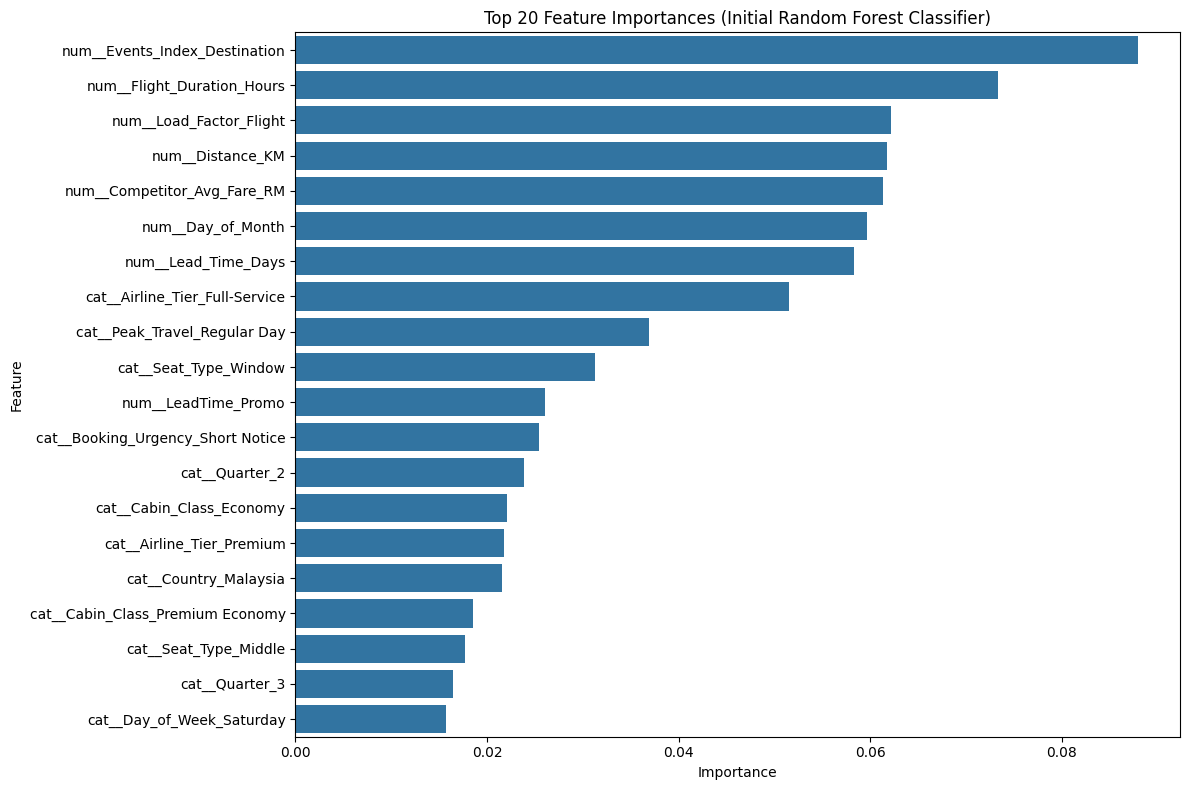

In [109]:
# Get feature importances from the Initial Random Forest model
importances = clf_model.feature_importances_

# Get feature names from the preprocessor
feature_names = preprocessor_clf.get_feature_names_out()

# Create a DataFrame for feature importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Top 20 Feature Importances (Initial Random Forest):")
print(feature_importance_df.head(20))

# Visualize top N feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20))
plt.title('Top 20 Feature Importances (Initial Random Forest Classifier)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The feature importance analysis of the selected Random Forest Classifier identified **Events_Index_Destination**, **Flight_Duration_Hours**, **Load_Factor_Flight**, **Distance_KM**, and **Lead_Time_Days** as the most influential predictors of flight delay status. These findings indicate that destination congestion, flight characteristics, passenger demand, and booking behaviour play significant roles in determining whether a flight is on time or delayed. From a business perspective, airlines can use these insights to improve operational planning by anticipating periods of high congestion, optimising flight schedules, allocating resources more effectively, and implementing proactive measures to reduce delays during high-risk operations.


# Conclusion

Future studies may incorporate customer segmentation techniques to group passengers with similar booking behaviours and travel preferences. Integrating these segments with the regression and classification models could enable more personalised pricing strategies and operational decision-making.

## Price

The results indicate that airline ticket prices are influenced by a combination of operational, market, and customer-related factors. Travel distance and cabin class were the strongest determinants of ticket prices, while promotional offers, competitor pricing, and booking lead time also contributed significantly. These findings demonstrate that airlines can improve pricing decisions by incorporating these variables into dynamic pricing models, enabling more competitive pricing strategies and more effective revenue management.

**Recommendation 1: Enhance Dynamic Pricing Strategy**

The regression model identified Distance_KM, Cabin_Class, and Competitor_Avg_Fare_RM as key factors influencing airline ticket prices. Airlines should incorporate these variables into their dynamic pricing strategy to adjust fares based on flight distance, service class, and prevailing market prices. This enables the airline to remain competitive while maximising revenue across different routes and customer segments.

**Recommendation 2: Optimise Promotional Campaigns**

The significance of Promo_Applied suggests that promotional offers have a considerable impact on ticket pricing. Airlines should implement targeted promotions based on booking behaviour, customer segments, and seasonal demand instead of offering blanket discounts. This approach can stimulate demand while protecting profit margins.

**Recommendation 3: Encourage Early Bookings**

Lead_Time_Days was identified as an important predictor of ticket prices, indicating that booking behaviour influences fare levels. Airlines can encourage customers to book earlier by offering early-bird discounts and personalised pricing incentives. Earlier bookings improve demand forecasting, capacity planning, and revenue management.

**Recommendation 4: Monitor Market Competition**

Since Competitor_Avg_Fare_RM was among the most influential variables, airlines should continuously monitor competitor pricing and adjust fares accordingly. A data-driven pricing strategy allows airlines to remain competitive while avoiding unnecessary revenue loss due to overpricing or underpricing.

## Delay

Based on the selected Random Forest Classifier, destination event congestion, flight duration, load factor, travel distance, booking lead time, and airline tier were identified as the primary factors influencing flight delay status. These findings suggest that flight delays are driven mainly by operational conditions, travel demand, and route characteristics rather than a single factor. By monitoring these variables, airlines can better anticipate potential delays, optimise resource allocation, and improve operational efficiency to enhance service reliability.

**Recommendation 1: Strengthen Operational Planning During High-Risk Periods**

Since Events_Index_Destination was the most influential factor affecting flight delays, airlines should closely monitor destination events such as festivals, concerts, and public gatherings. Additional operational resources, including staff and aircraft, can be allocated during these periods to minimise disruptions and improve on-time performance.

**Recommendation 2: Improve Flight Scheduling and Capacity Management**

Flight_Duration_Hours and Load_Factor_Flight were among the most important predictors of delay status. Airlines should optimise flight schedules by allowing sufficient turnaround time for longer flights and closely managing aircraft capacity during high-demand periods to reduce operational bottlenecks.

**Recommendation 3: Enhance Route and Demand Monitoring**

The importance of Distance_KM and Lead_Time_Days suggests that route characteristics and booking patterns influence flight delays. Airlines should use predictive analytics to identify high-risk routes and booking periods, enabling proactive scheduling adjustments and more efficient allocation of operational resources.

**Recommendation 4: Support Data-Driven Operational Decision-Making**

Airlines should integrate the developed machine learning model into their operational decision-making processes to identify flights with a higher likelihood of delays. Early predictions can support gate allocation, crew scheduling, passenger communication, and contingency planning, ultimately improving service reliability and customer satisfaction.